In [1]:
%load_ext autoreload
%autoreload 2
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.append("/home/sambt/CASE_final/CASE_QUAK_final/commonTools/")
import helper_functions as hf
import qRegNN_NFs_general as qrnn
import qRegNN_NFs_general_allInOne as qrnn2
import sklearn
import scipy
import sklearn.datasets as datasets
import h5py
import os
import pandas as pd
import corner
from sklearn.model_selection import train_test_split
sys.path.append("/home/sambt/SINF/")
sys.path.append("/home/sambt/SINF/sinf/")
from GIS import GIS
import torch
import torch.nn as nn
device = torch.device('cuda:0')
import uproot
from tqdm import tqdm
import h5py

In [2]:
# make train/test/val split indices for R&D dataset bkg
base = "/nobackup/users/sambt/QR_samples/LHCO/"
f_rd = f"{base}/rd/RD/merged.h5"
with h5py.File(f_rd,"r") as frd:
    label = frd['label'][()]
    mask = label==0
    nevents = np.count_nonzero(mask)
indices = np.arange(nevents)
train_idx, test_idx = train_test_split(indices,train_size=0.5,random_state=76512)
test_idx, val_idx = train_test_split(test_idx,train_size=0.5,random_state=93014)
with h5py.File(base+"rd/RD/split_indices.h5","w") as fout:
    fout.create_dataset("train_inds",data=train_idx)
    fout.create_dataset("test_inds",data=test_idx)
    fout.create_dataset("val_inds",data=val_idx)

In [2]:
base = "/nobackup/users/sambt/QR_samples/LHCO/"
f_bb1 = f"{base}/challenge/BB1/merged.h5"
f_ind_bb1 = f"{base}/challenge/BB1/split_indices.h5"
f_rd = f"{base}/rd/RD/merged.h5"
f_ind_rd = f"{base}/rd/RD/split_indices.h5"


fitvars = ['jet1_rho','jet1_tau21','jet1_tau32','jet1_tau43',
           'jet2_rho','jet2_tau21','jet2_tau32','jet2_tau43']

with h5py.File(f_ind_rd,'r') as f:
    rd_test_idx = f['test_inds'][()]
    rd_train_idx = f['train_inds'][()]
    
with h5py.File(f_ind_bb1,'r') as f:
    bb1_test_idx = f['test_inds'][()]
    bb1_train_idx = f['train_inds'][()]
    
with h5py.File(f_bb1,"r") as fp_b1:
    labels_b1 = np.loadtxt(f"{base}/challenge/BB1/events_LHCO2020_BlackBox1.masterkey")
    b1_test = np.concatenate([fp_b1[v][()][labels_b1==0].reshape(-1,1) for v in fitvars],axis=1)[bb1_test_idx]
    b1_train = np.concatenate([fp_b1[v][()][labels_b1==0].reshape(-1,1) for v in fitvars],axis=1)[bb1_train_idx]
    
with h5py.File(f_rd,"r") as frd:
    label = frd['label'][()]
    mask = label==0
    rd_test = np.concatenate([frd[v][()][mask].reshape(-1,1) for v in fitvars],axis=1)[rd_test_idx]
    rd_train = np.concatenate([frd[v][()][mask].reshape(-1,1) for v in fitvars],axis=1)[rd_train_idx]

# Train flows

In [3]:
NF_kwargs = {"flow_type":"IRQS","tail_bound":3.2,"hidden_features":100,
             "num_layers":5,"num_bins":15,"num_blocks_per_layer":5,"tails":"linear",
            "dropout":0.0,"residual":False}
rangeScale = 3
variables = fitvars
trainer = qrnn.chainedNFTrainer("LHCO_BB1toPythRD_jets12",b1_train,b1_test,rd_train,rd_test,fitvars,control=[],
                                NF_kwargs=NF_kwargs,rangeScale=rangeScale,separateScale=False)

## jet1 rho

Training flow bkgFlow_step0_jet1_rho


Loss: 1.3297361934185028, p = 97: 100%|██████████| 609/609 [01:08<00:00,  8.95it/s] 


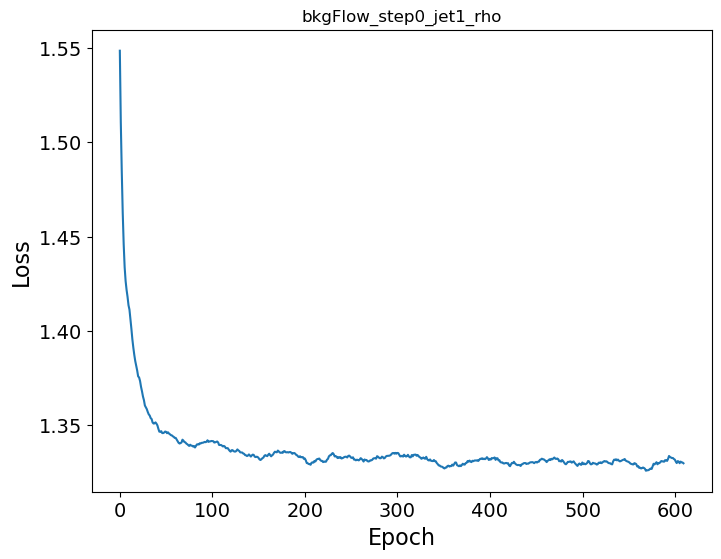

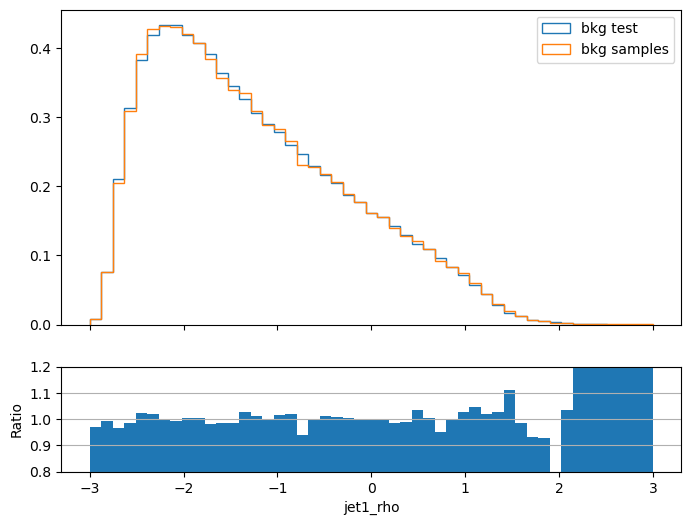

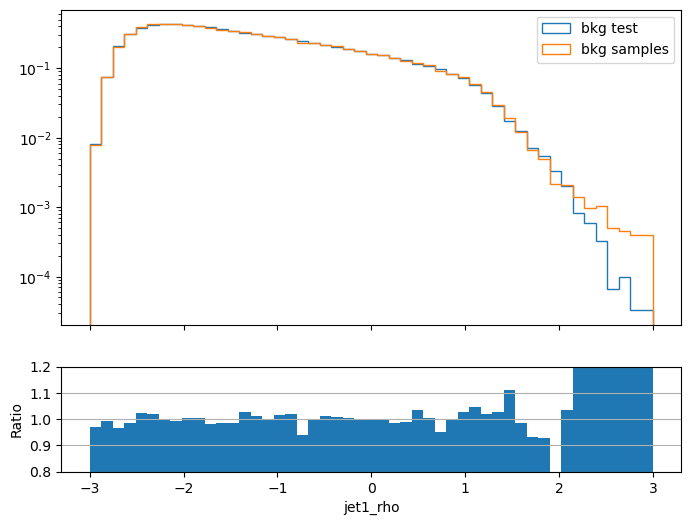

In [21]:
NF_kwargs = {"flow_type":"IRQS","tail_bound":3.2,"hidden_features":100,
             "num_layers":5,"num_bins":30,"num_blocks_per_layer":5,"tails":"linear",
            "dropout":0.0,"residual":False}
trainer.NF_kwargs = NF_kwargs
bs = 4096
n_epoch = 5
n_iter = n_epoch*b1_train.shape[0]//bs
trainer.trainCurrentBkg(patience=-1,n_epoch=n_iter,learning_rate=1e-3,bs=bs)
trainer.plotDensity(bkg=True)

Training flow dataFlow_step0_jet1_rho


Loss: 1.2770919978618622, p = 37: 100%|██████████| 250/250 [00:50<00:00,  4.93it/s]


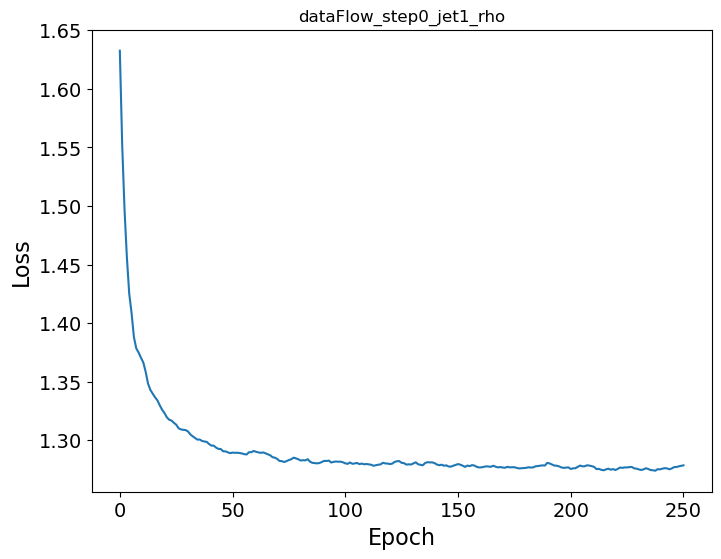

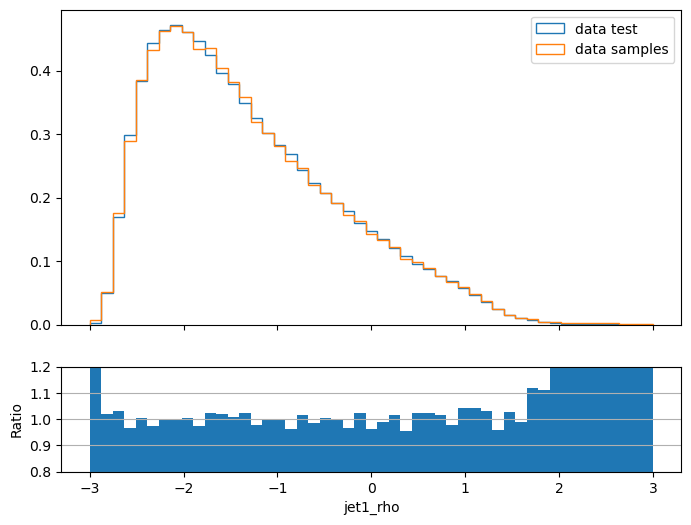

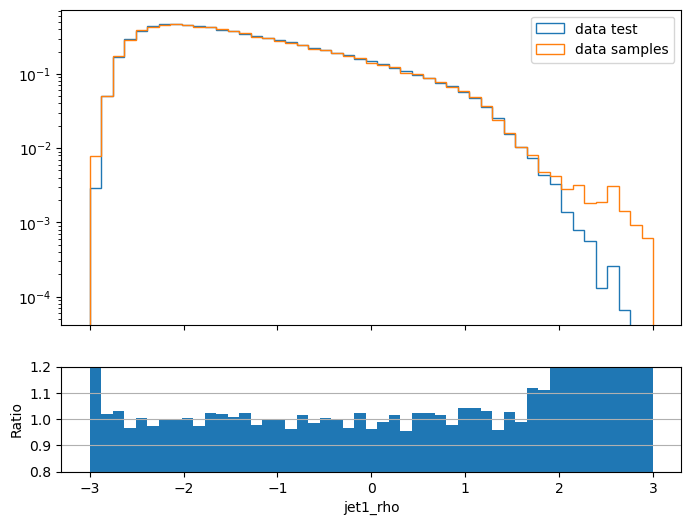

In [23]:
NF_kwargs = {"flow_type":"IRQS","tail_bound":3.2,"hidden_features":100,
             "num_layers":5,"num_bins":30,"num_blocks_per_layer":5,"tails":"linear",
            "dropout":0.0,"residual":False}
trainer.NF_kwargs = NF_kwargs
bs = 10000
n_epoch = 5
n_iter = n_epoch*rd_train.shape[0]//bs
trainer.trainCurrentData(patience=-1,n_epoch=n_iter,learning_rate=1e-3,bs=bs)
trainer.plotDensity(data=True)

100%|██████████| 25/25 [00:01<00:00, 14.90it/s]


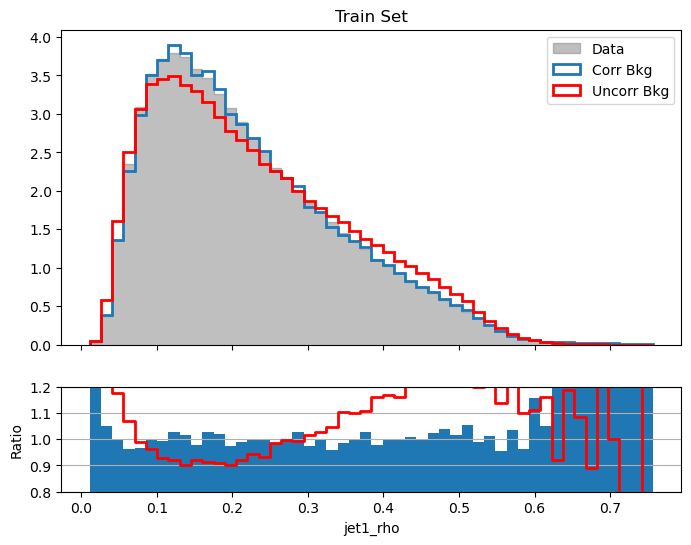

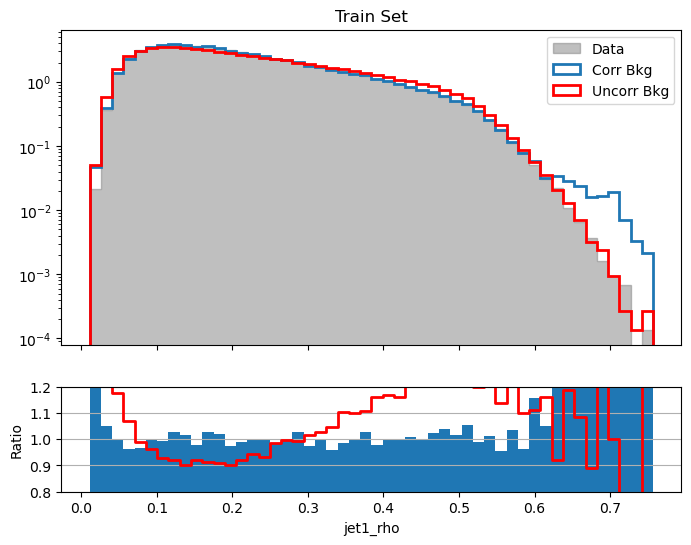

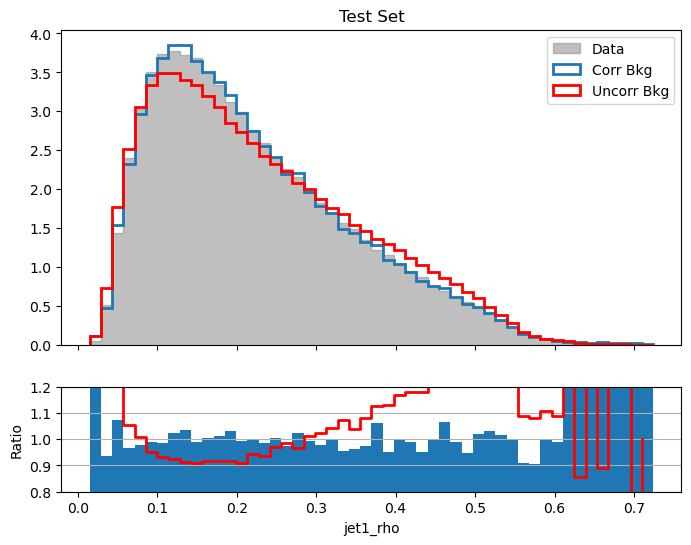

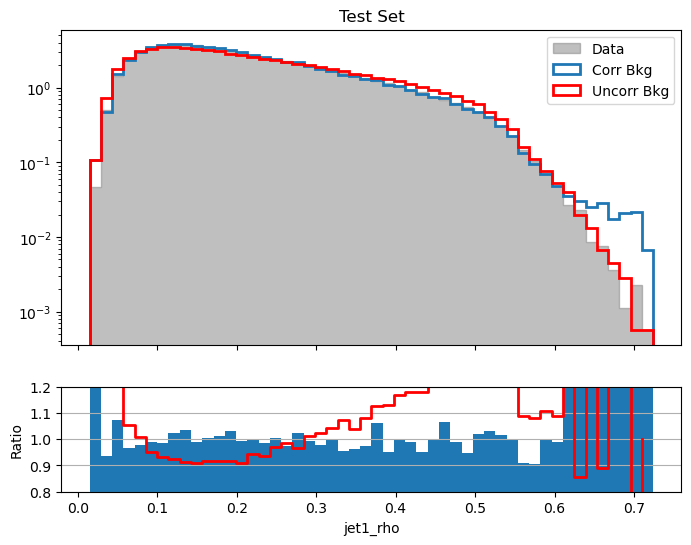

In [24]:
trainer.correctCurrent()
trainer.plotCurrent(50)

In [25]:
trainer.stepForward()

## jet1 tau21

Training flow bkgFlow_step1_jet1_tau21


Loss: 1.3681203079223634, p = 33: 100%|██████████| 249/249 [00:50<00:00,  4.90it/s]


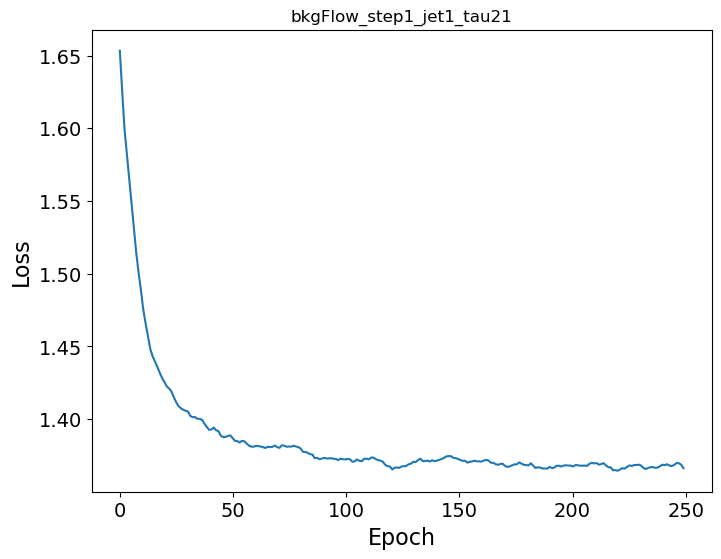

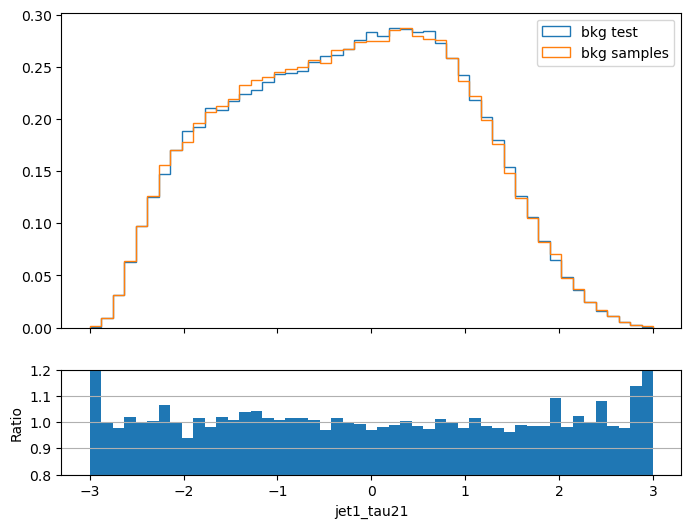

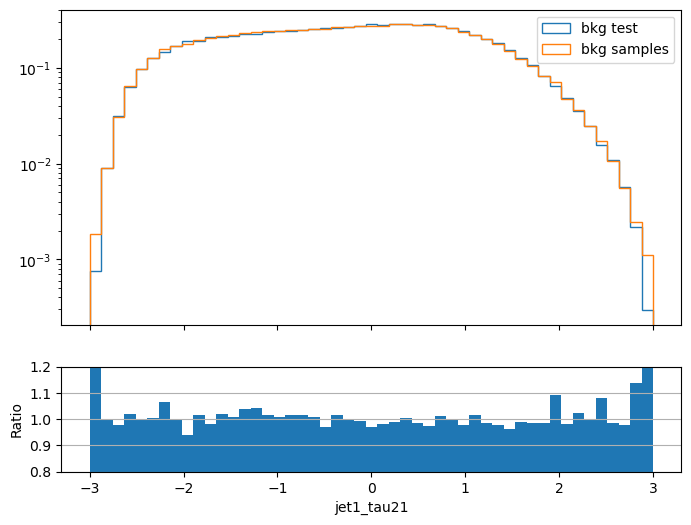

In [45]:
NF_kwargs = {"flow_type":"IRQS","tail_bound":3.2,"hidden_features":100,
             "num_layers":5,"num_bins":30,"num_blocks_per_layer":5,"tails":"linear",
            "dropout":0.0,"residual":False}
trainer.NF_kwargs = NF_kwargs
bs = 10000
n_epoch = 5
n_iter = n_epoch*b1_train.shape[0]//bs
trainer.trainCurrentBkg(patience=-1,n_epoch=n_iter,learning_rate=1e-3,bs=bs)
trainer.plotDensity(bkg=True)

Training flow dataFlow_step1_jet1_tau21


Loss: 1.3552197909355164, p = 39: 100%|██████████| 500/500 [01:42<00:00,  4.88it/s] 


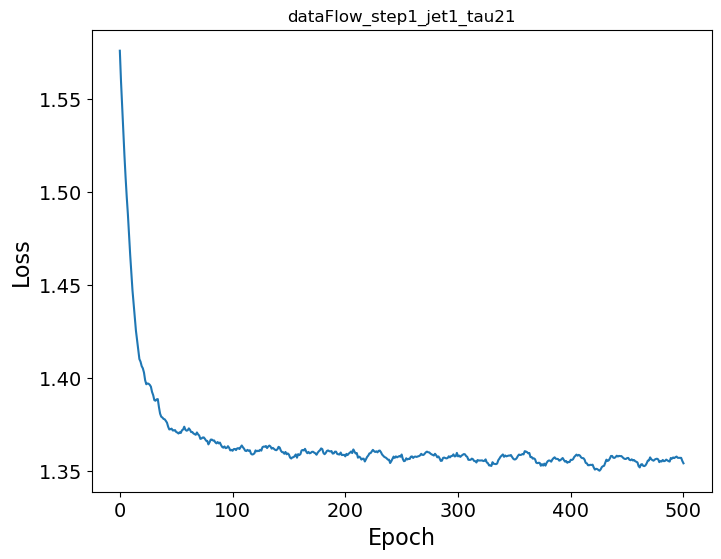

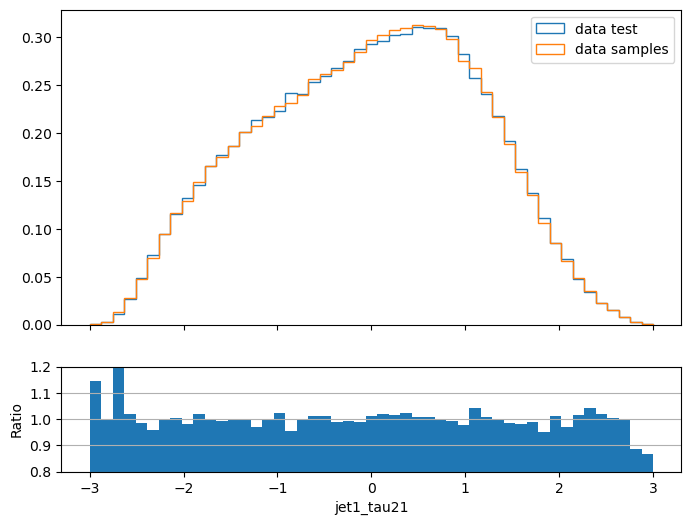

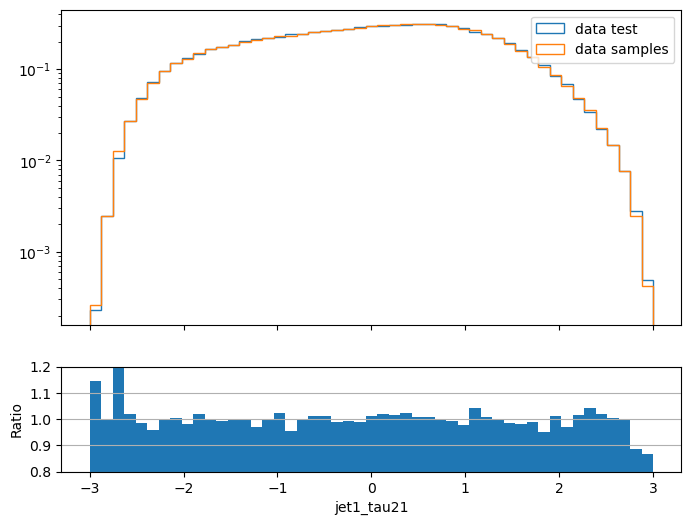

In [29]:
NF_kwargs = {"flow_type":"IRQS","tail_bound":3.2,"hidden_features":100,
             "num_layers":5,"num_bins":30,"num_blocks_per_layer":5,"tails":"linear",
            "dropout":0.0,"residual":False}
trainer.NF_kwargs = NF_kwargs
bs = 10000
n_epoch = 10
n_iter = n_epoch*rd_train.shape[0]//bs
trainer.trainCurrentData(patience=-1,n_epoch=n_iter,learning_rate=1e-3,bs=bs)
trainer.plotDensity(data=True)

100%|██████████| 25/25 [00:01<00:00, 14.96it/s]


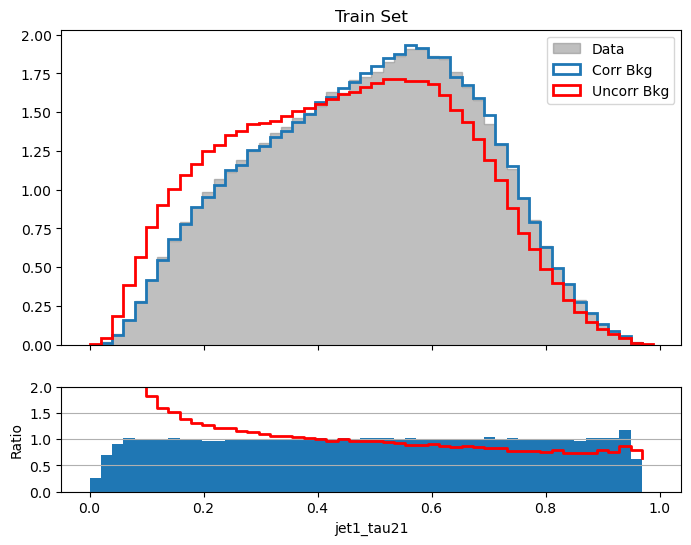

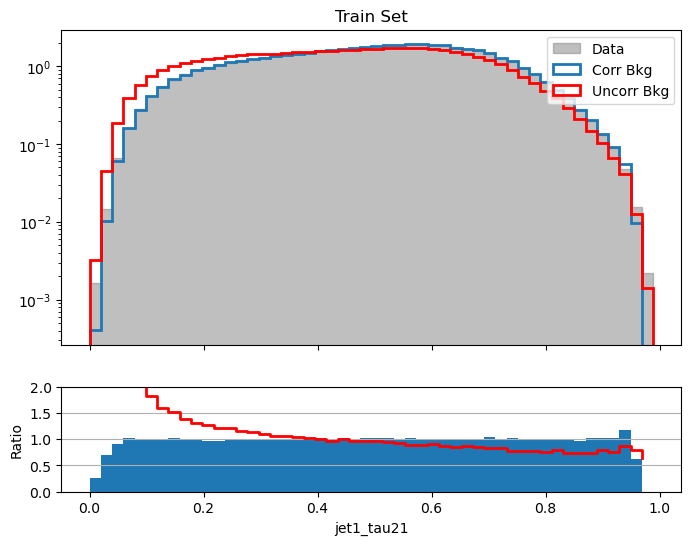

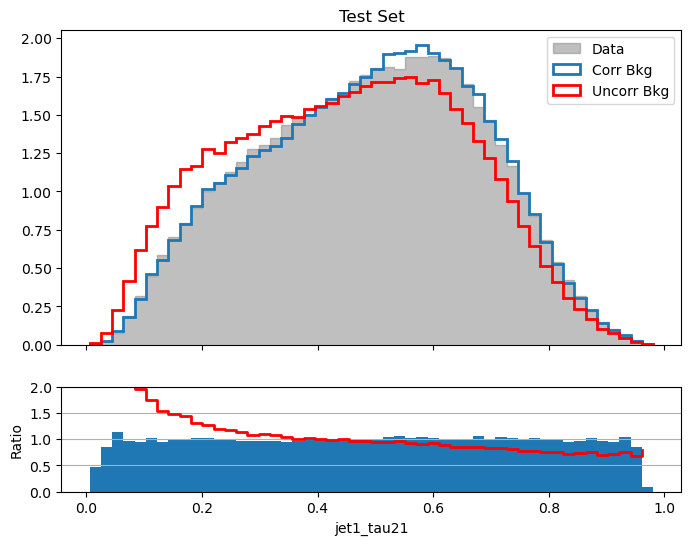

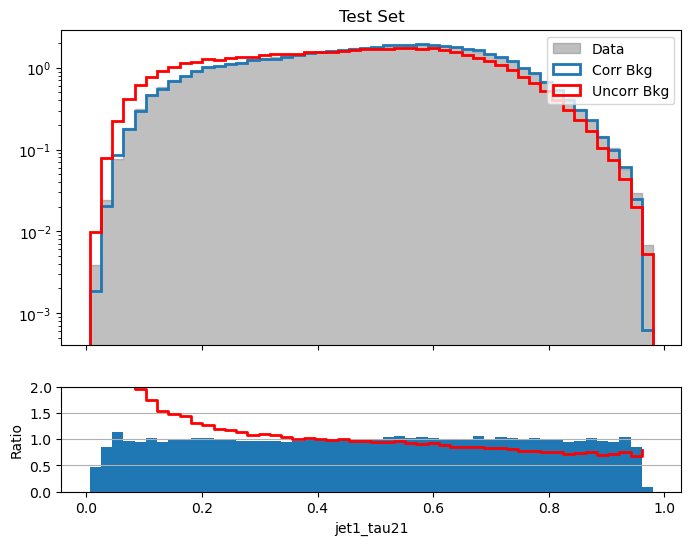

In [46]:
trainer.correctCurrent()
trainer.plotCurrent(50,ylim=[0,2])

In [47]:
trainer.stepForward()

## jet1 tau32

Training flow bkgFlow_step2_jet1_tau32


Loss: 0.8947156625986099, p = 605: 100%|██████████| 1219/1219 [02:19<00:00,  8.76it/s]


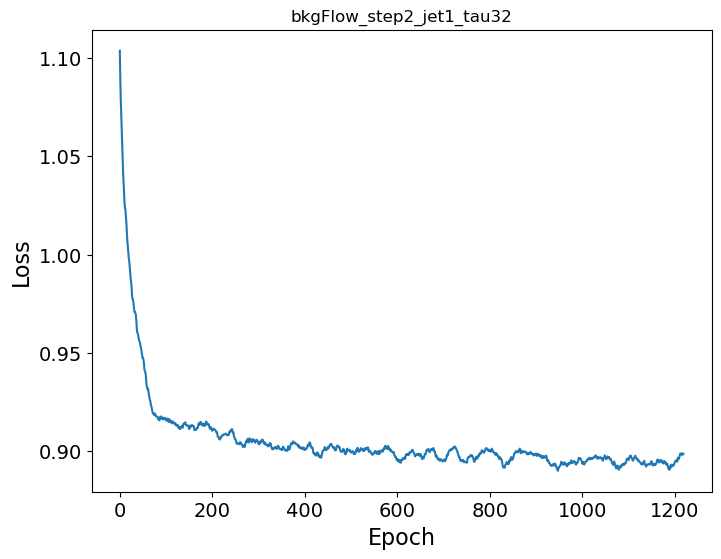

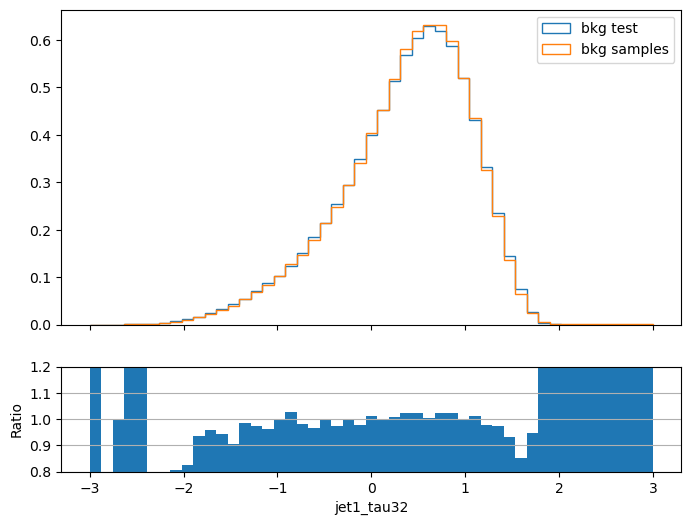

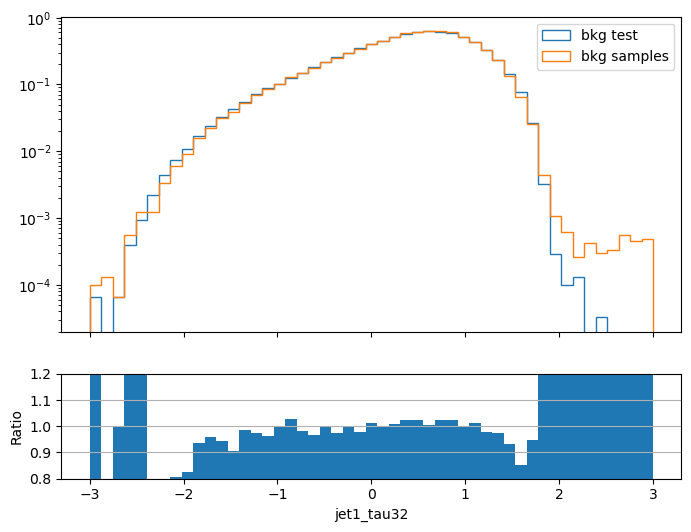

In [51]:
NF_kwargs = {"flow_type":"IRQS","tail_bound":3.2,"hidden_features":150,
             "num_layers":5,"num_bins":50,"num_blocks_per_layer":5,"tails":"linear",
            "dropout":0.0,"residual":False}
trainer.NF_kwargs = NF_kwargs
bs = 4096
n_epoch = 10
n_iter = n_epoch*b1_train.shape[0]//bs
trainer.trainCurrentBkg(patience=-1,n_epoch=n_iter,learning_rate=1e-3,bs=bs)
trainer.plotDensity(bkg=True)

Training flow dataFlow_step2_jet1_tau32


Loss: 0.8345050776004791, p = 236: 100%|██████████| 1220/1220 [02:31<00:00,  8.04it/s]


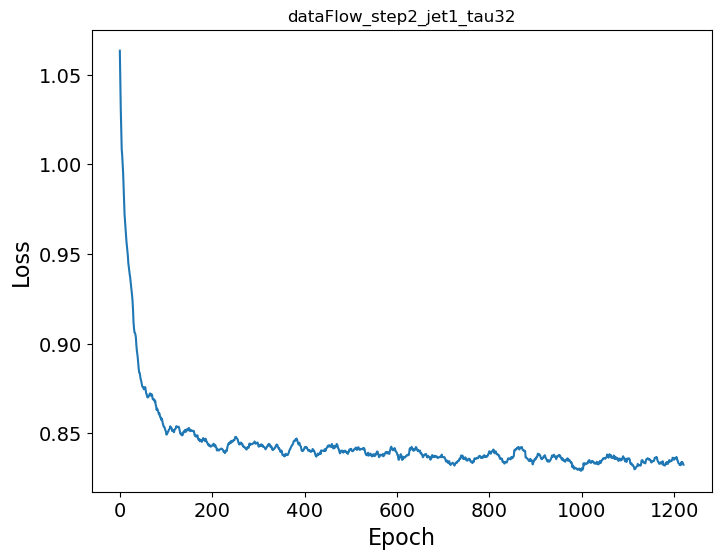

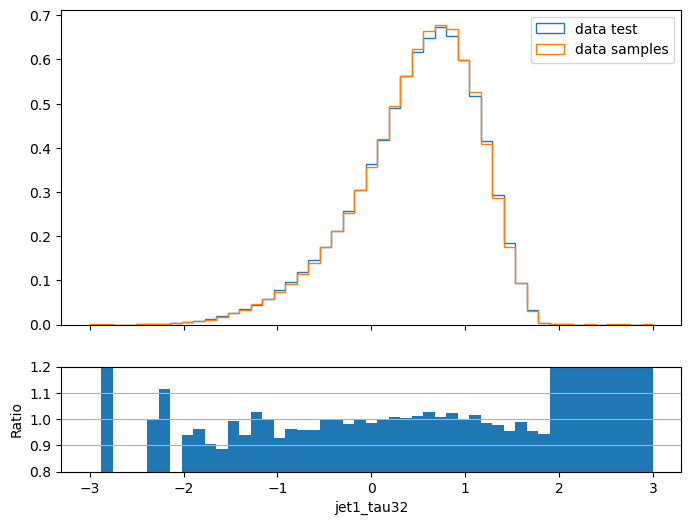

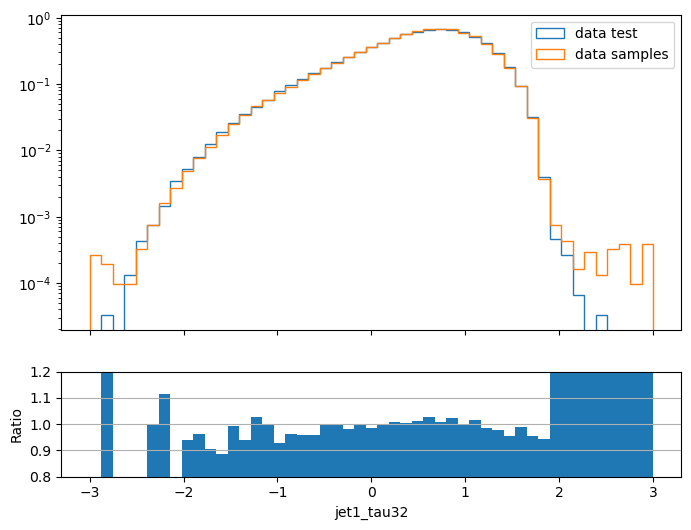

In [52]:
NF_kwargs = {"flow_type":"IRQS","tail_bound":3.2,"hidden_features":150,
             "num_layers":5,"num_bins":50,"num_blocks_per_layer":5,"tails":"linear",
            "dropout":0.0,"residual":False}
trainer.NF_kwargs = NF_kwargs
bs = 4096
n_epoch = 10
n_iter = n_epoch*rd_train.shape[0]//bs
trainer.trainCurrentData(patience=-1,n_epoch=n_iter,learning_rate=1e-3,bs=bs)
trainer.plotDensity(data=True)

100%|██████████| 25/25 [00:02<00:00, 11.51it/s]


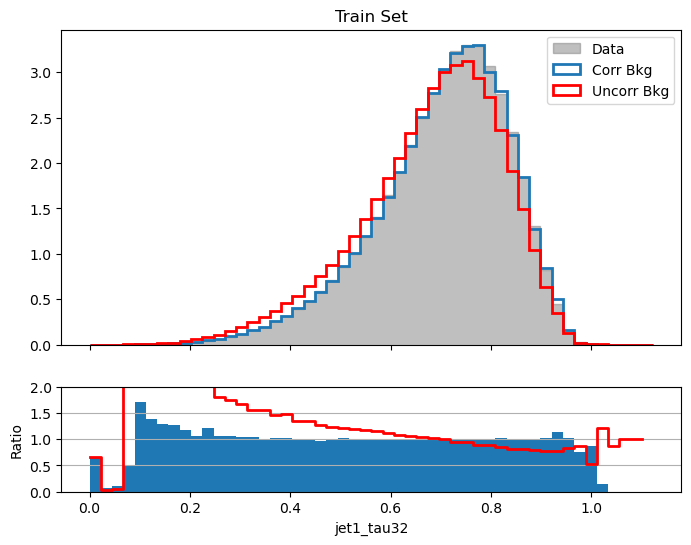

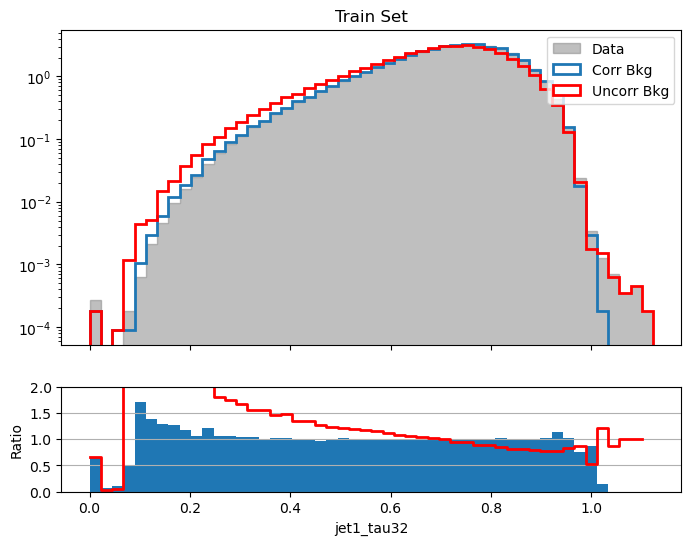

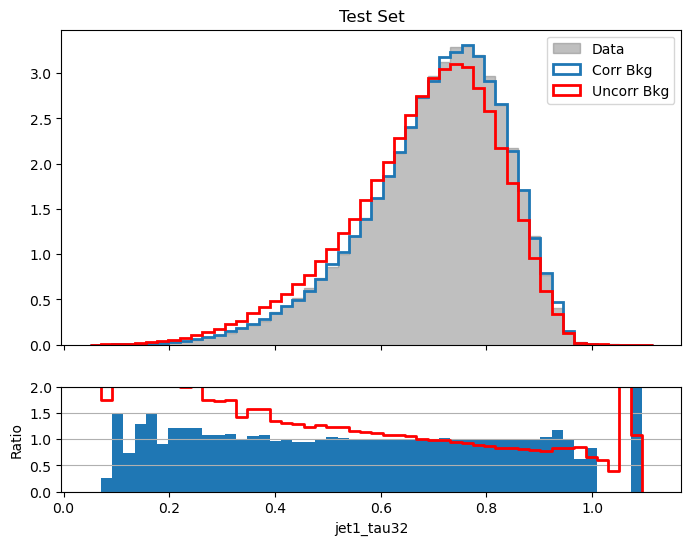

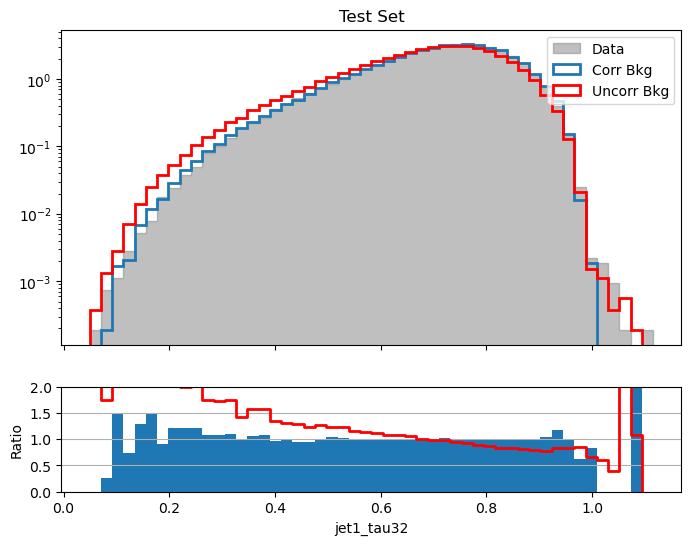

In [53]:
trainer.correctCurrent()
trainer.plotCurrent(50,ylim=[0,2])

In [54]:
trainer.stepForward()

## jet1 tau43

Training flow bkgFlow_step3_jet1_tau43


Loss: 0.4345163303613663, p = 65: 100%|██████████| 1219/1219 [02:20<00:00,  8.66it/s]  


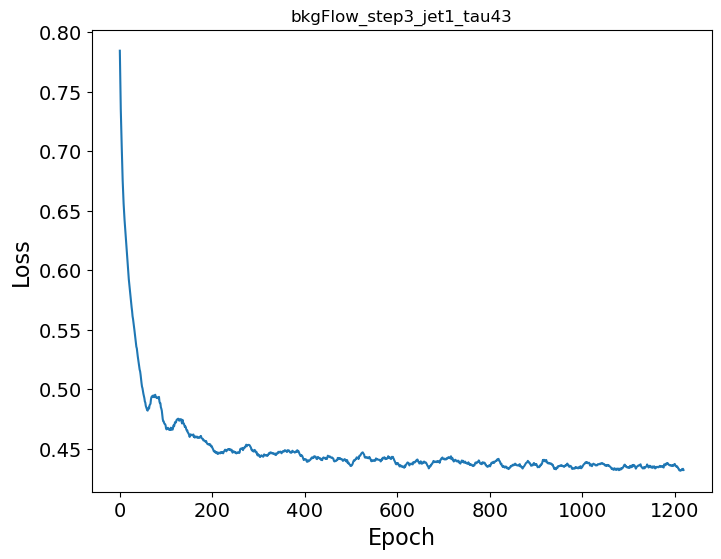

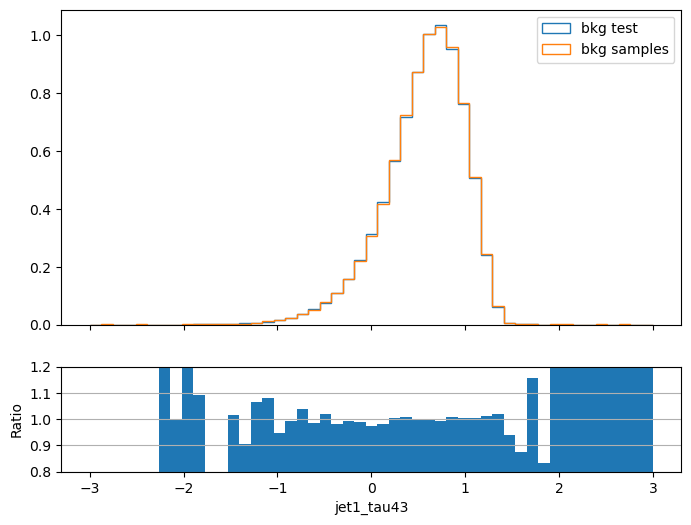

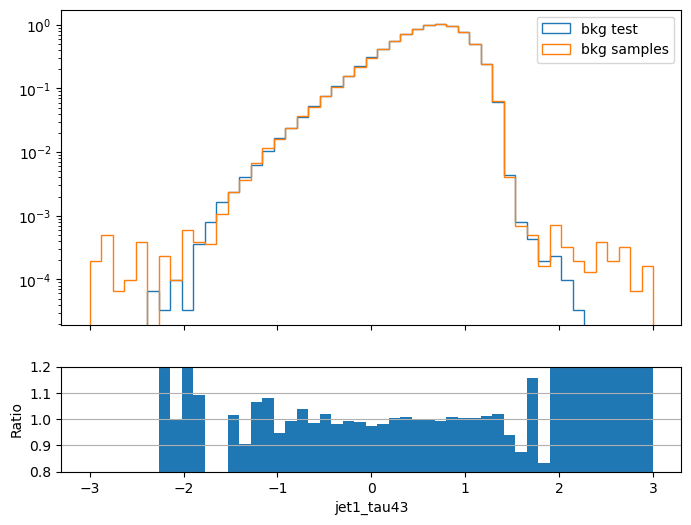

In [55]:
NF_kwargs = {"flow_type":"IRQS","tail_bound":3.2,"hidden_features":150,
             "num_layers":5,"num_bins":50,"num_blocks_per_layer":5,"tails":"linear",
            "dropout":0.0,"residual":False}
trainer.NF_kwargs = NF_kwargs
bs = 4096
n_epoch = 10
n_iter = n_epoch*b1_train.shape[0]//bs
trainer.trainCurrentBkg(patience=-1,n_epoch=n_iter,learning_rate=1e-3,bs=bs)
trainer.plotDensity(bkg=True)

Training flow dataFlow_step3_jet1_tau43


Loss: 0.36798199951648713, p = 37: 100%|██████████| 500/500 [01:54<00:00,  4.36it/s] 


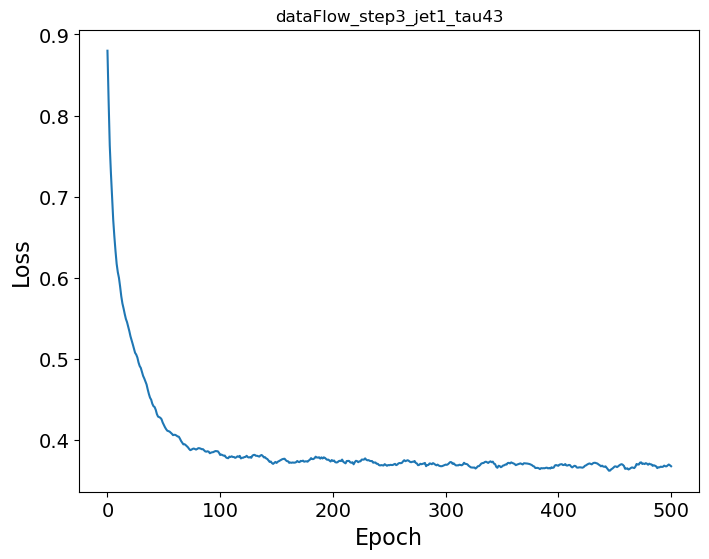

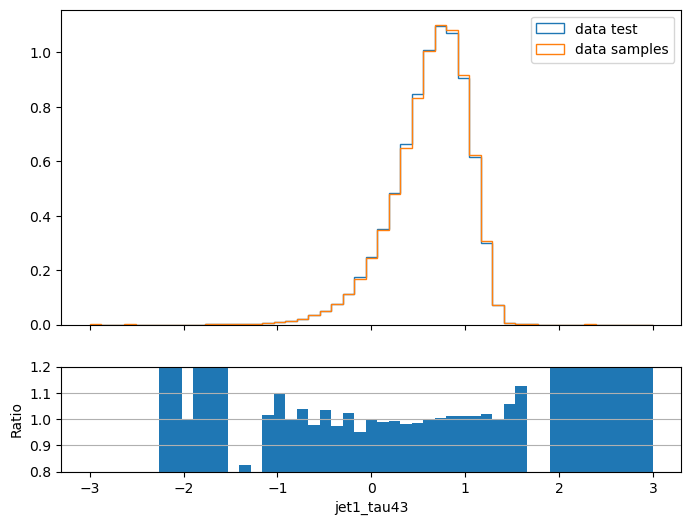

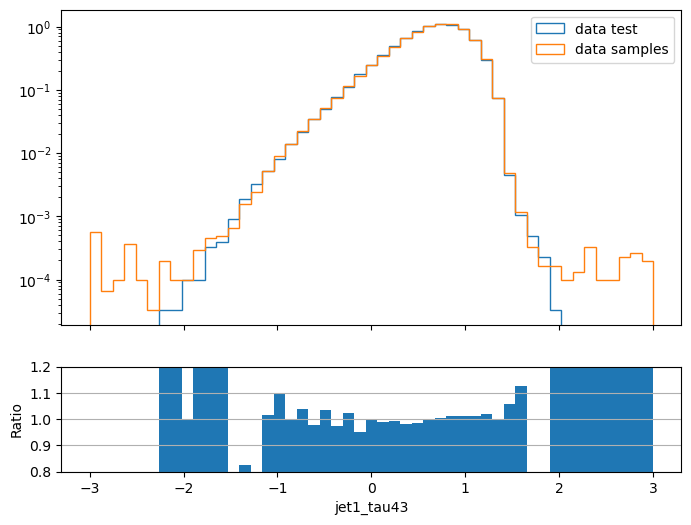

In [57]:
NF_kwargs = {"flow_type":"IRQS","tail_bound":3.2,"hidden_features":150,
             "num_layers":5,"num_bins":50,"num_blocks_per_layer":5,"tails":"linear",
            "dropout":0.0,"residual":False}
trainer.NF_kwargs = NF_kwargs
bs = 10000
n_epoch = 10
n_iter = n_epoch*rd_train.shape[0]//bs
trainer.trainCurrentData(patience=-1,n_epoch=n_iter,learning_rate=1e-3,bs=bs)
trainer.plotDensity(data=True)

100%|██████████| 25/25 [00:02<00:00, 12.43it/s]


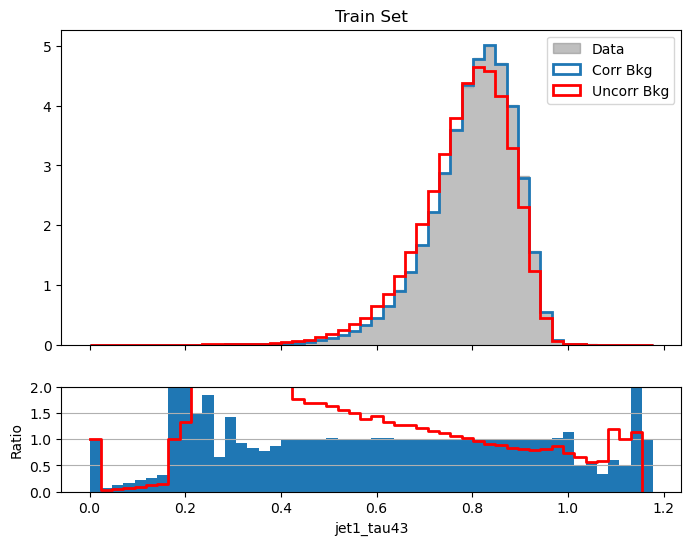

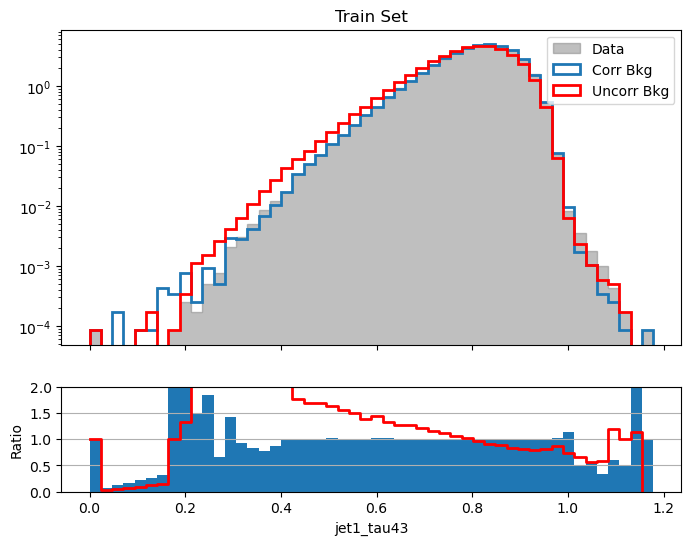

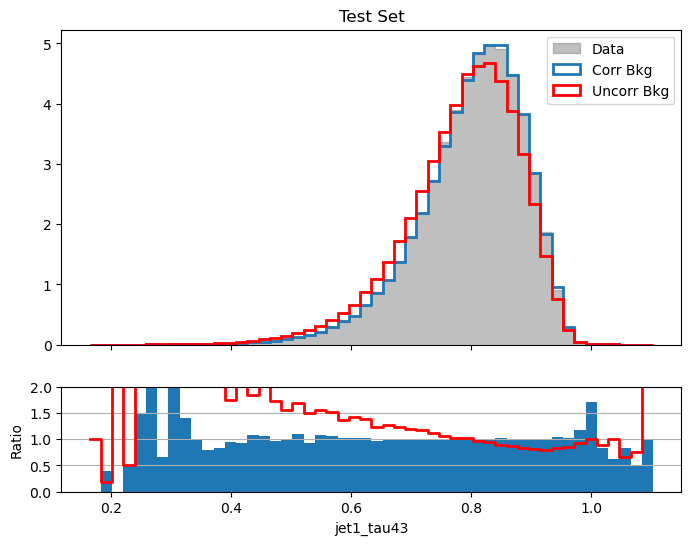

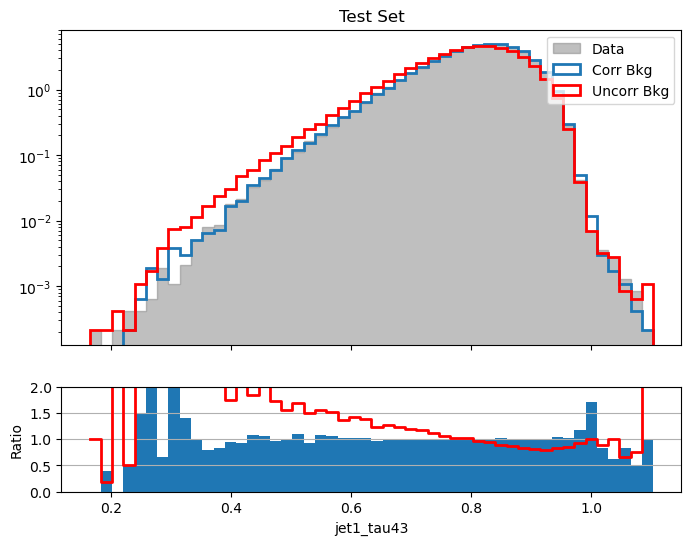

In [58]:
trainer.correctCurrent()
trainer.plotCurrent(50,ylim=[0,2])

In [59]:
trainer.stepForward()

## jet2 rho

Training flow bkgFlow_step4_jet2_rho


Loss: 0.5429009753465652, p = 313: 100%|██████████| 1219/1219 [02:33<00:00,  7.95it/s]


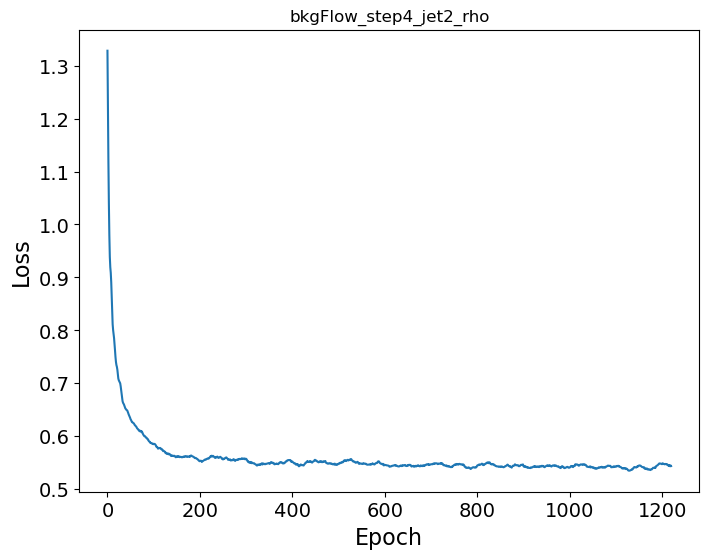

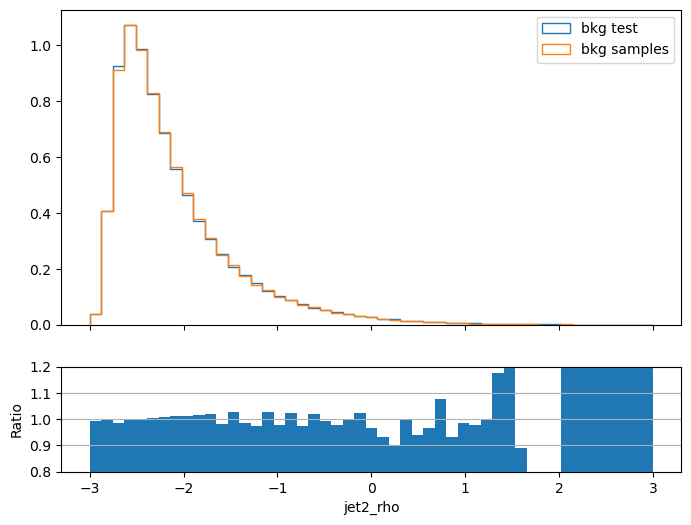

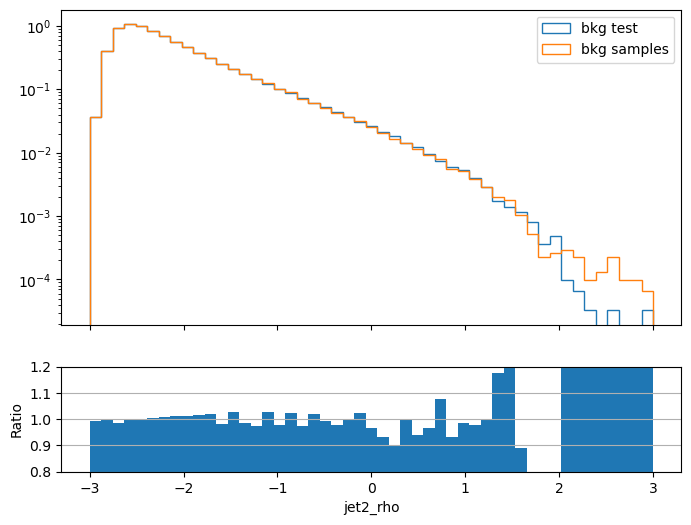

In [60]:
NF_kwargs = {"flow_type":"IRQS","tail_bound":3.2,"hidden_features":150,
             "num_layers":5,"num_bins":50,"num_blocks_per_layer":5,"tails":"linear",
            "dropout":0.0,"residual":False}
trainer.NF_kwargs = NF_kwargs
bs = 4096
n_epoch = 10
n_iter = n_epoch*b1_train.shape[0]//bs
trainer.trainCurrentBkg(patience=-1,n_epoch=n_iter,learning_rate=1e-3,bs=bs)
trainer.plotDensity(bkg=True)

Training flow dataFlow_step4_jet2_rho


Loss: 0.47876140505075454, p = 1: 100%|██████████| 500/500 [01:46<00:00,  4.70it/s]  


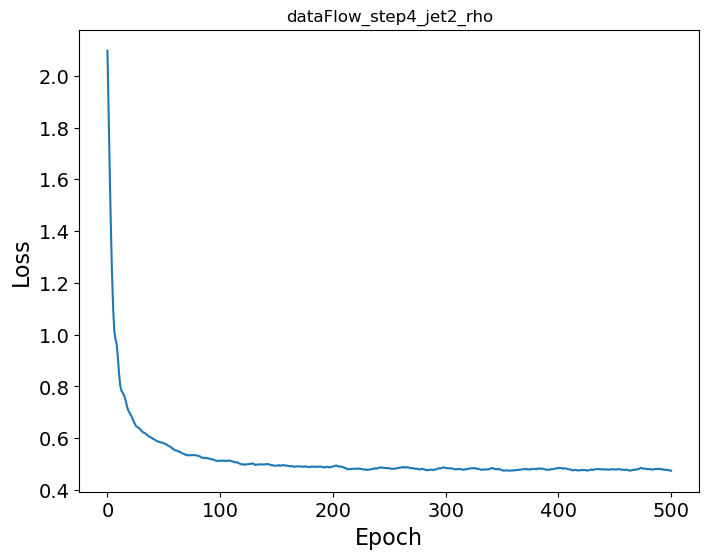

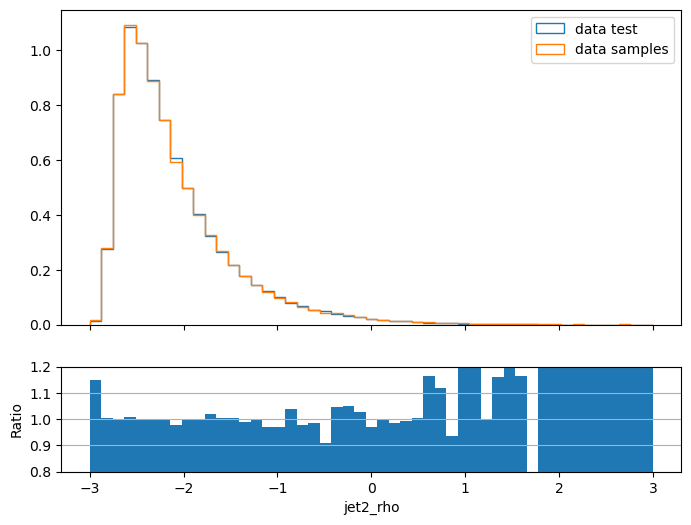

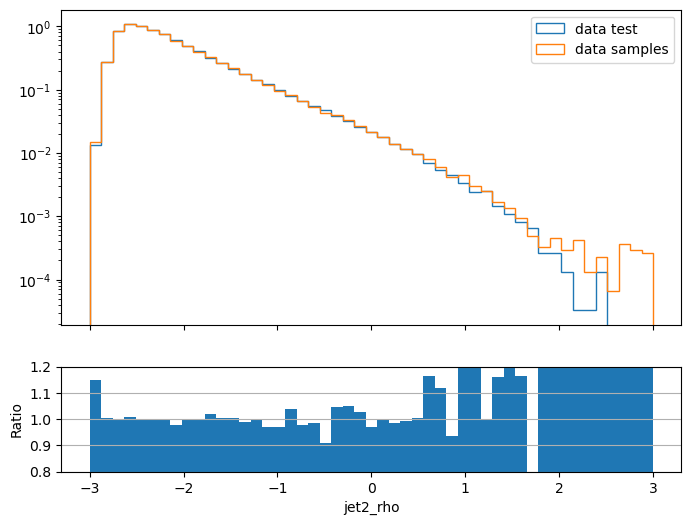

In [61]:
NF_kwargs = {"flow_type":"IRQS","tail_bound":3.2,"hidden_features":150,
             "num_layers":5,"num_bins":50,"num_blocks_per_layer":5,"tails":"linear",
            "dropout":0.0,"residual":False}
trainer.NF_kwargs = NF_kwargs
bs = 10000
n_epoch = 10
n_iter = n_epoch*rd_train.shape[0]//bs
trainer.trainCurrentData(patience=-1,n_epoch=n_iter,learning_rate=1e-3,bs=bs)
trainer.plotDensity(data=True)

100%|██████████| 25/25 [00:02<00:00, 11.76it/s]


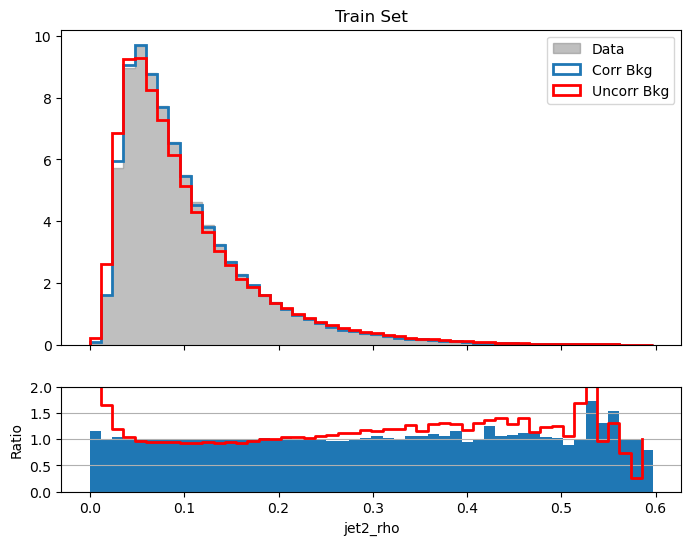

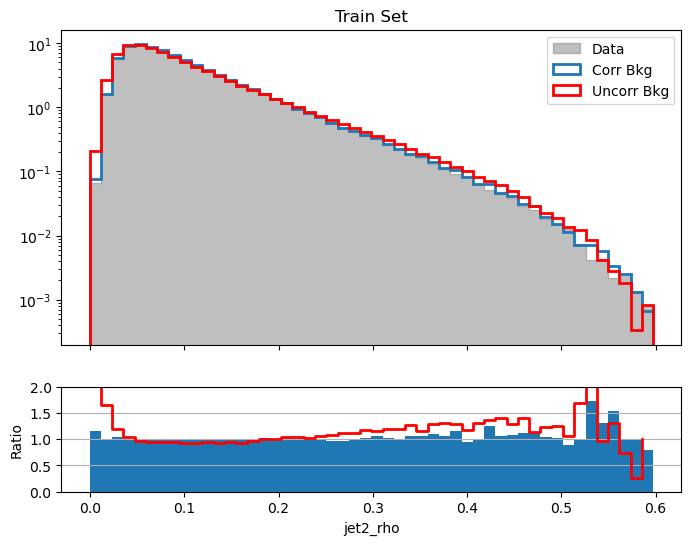

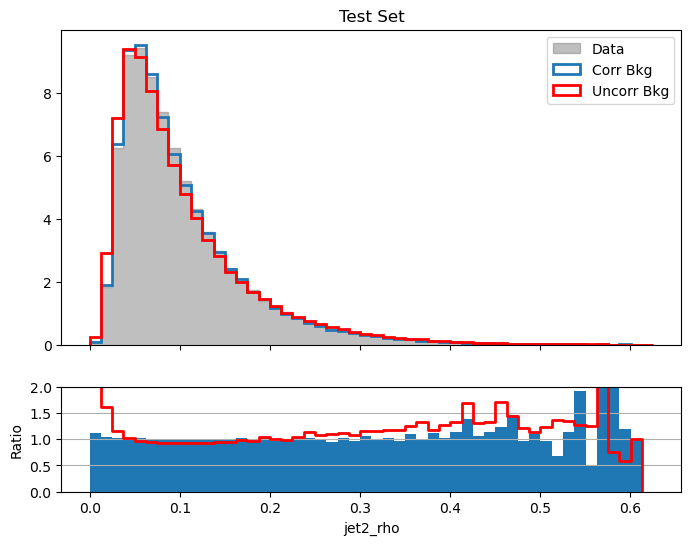

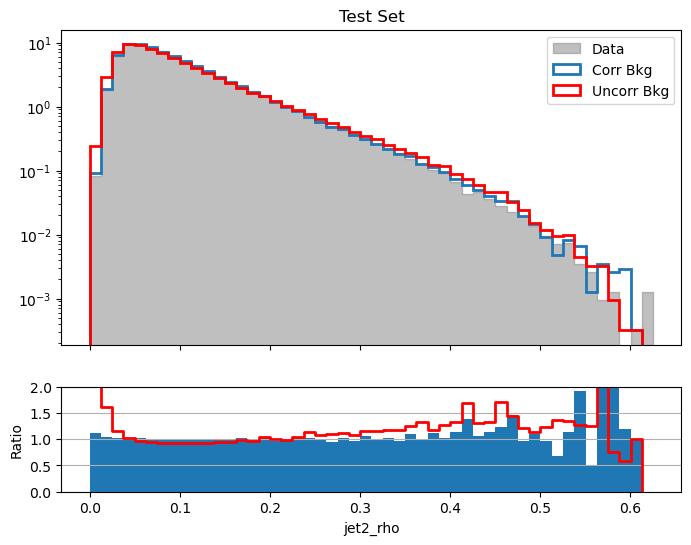

In [62]:
trainer.correctCurrent()
trainer.plotCurrent(50,ylim=[0,2])

In [63]:
trainer.stepForward()

## jet2 tau21

Training flow bkgFlow_step5_jet2_tau21


Loss: 1.4035840404033662, p = 18: 100%|██████████| 499/499 [01:41<00:00,  4.91it/s] 


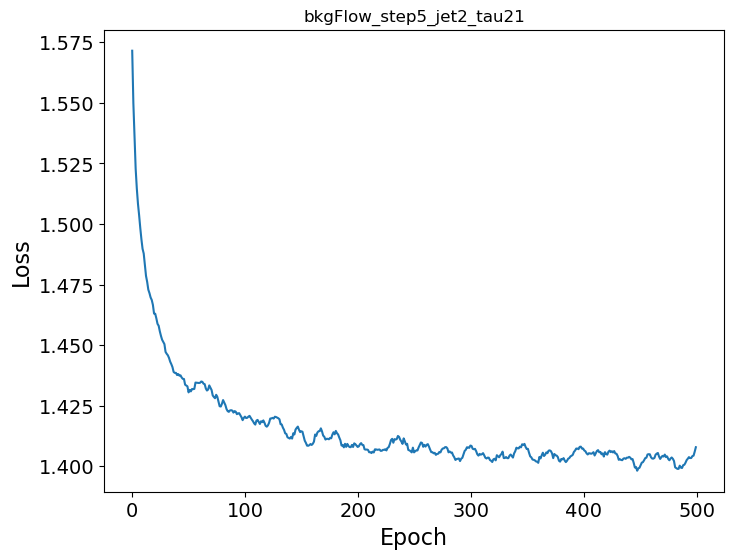

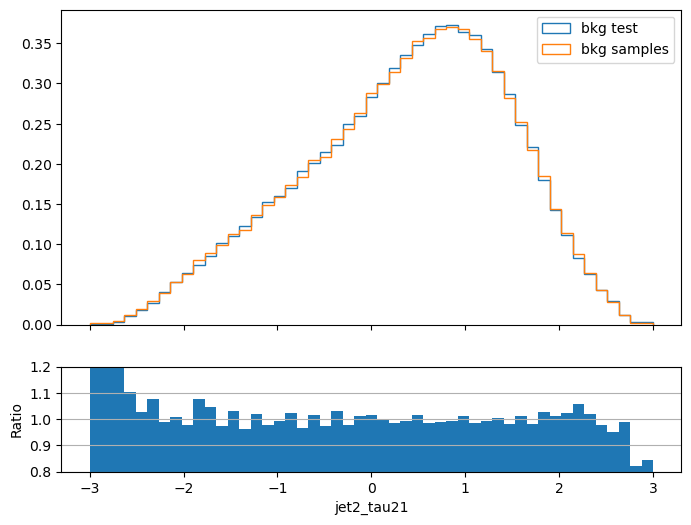

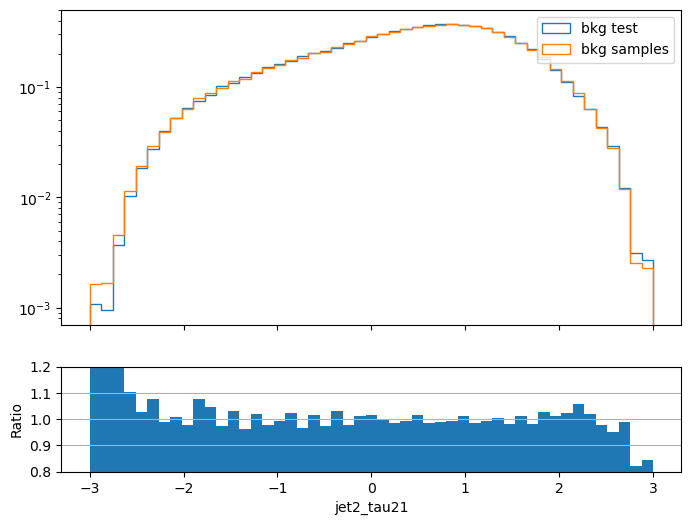

In [65]:
NF_kwargs = {"flow_type":"IRQS","tail_bound":3.2,"hidden_features":150,
             "num_layers":5,"num_bins":50,"num_blocks_per_layer":5,"tails":"linear",
            "dropout":0.0,"residual":False}
trainer.NF_kwargs = NF_kwargs
bs = 10000
n_epoch = 10
n_iter = n_epoch*b1_train.shape[0]//bs
trainer.trainCurrentBkg(patience=-1,n_epoch=n_iter,learning_rate=1e-3,bs=bs)
trainer.plotDensity(bkg=True)

Training flow dataFlow_step5_jet2_tau21


Loss: 1.3687023675441743, p = 12: 100%|██████████| 500/500 [01:42<00:00,  4.90it/s] 


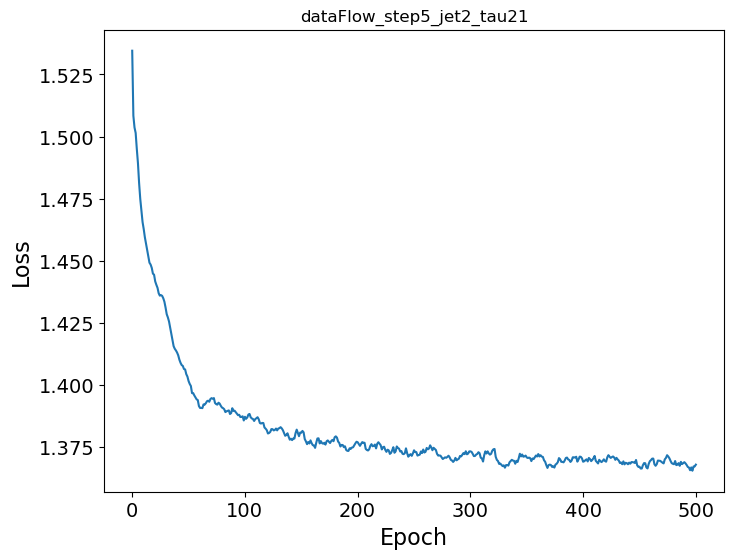

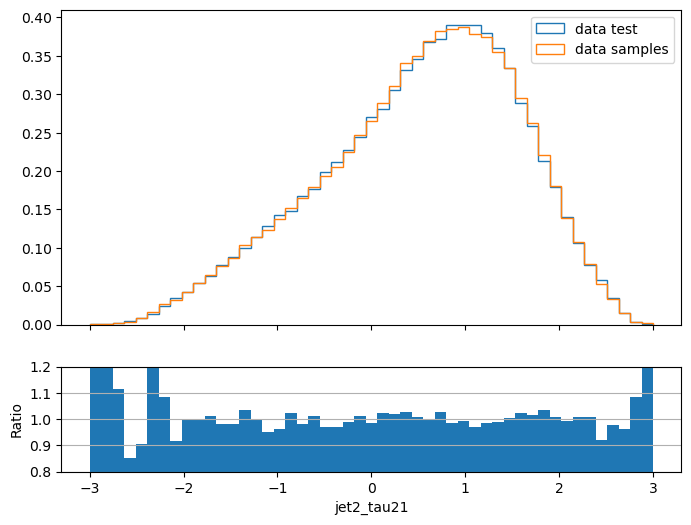

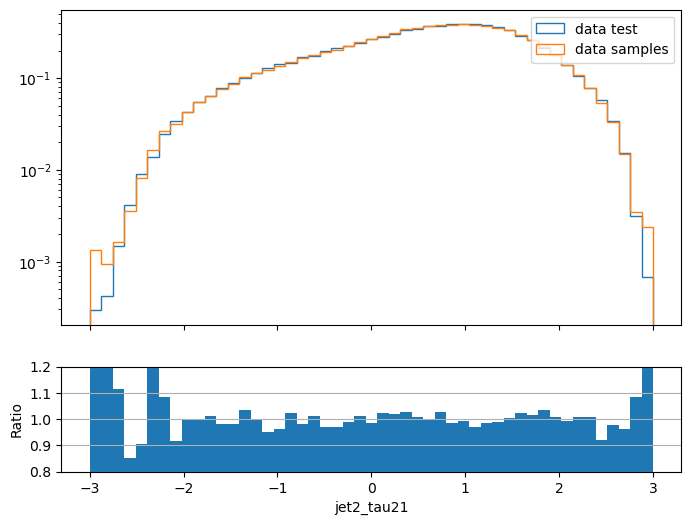

In [66]:
NF_kwargs = {"flow_type":"IRQS","tail_bound":3.2,"hidden_features":150,
             "num_layers":5,"num_bins":50,"num_blocks_per_layer":5,"tails":"linear",
            "dropout":0.0,"residual":False}
trainer.NF_kwargs = NF_kwargs
bs = 10000
n_epoch = 10
n_iter = n_epoch*rd_train.shape[0]//bs
trainer.trainCurrentData(patience=-1,n_epoch=n_iter,learning_rate=1e-3,bs=bs)
trainer.plotDensity(data=True)

100%|██████████| 25/25 [00:02<00:00, 11.86it/s]


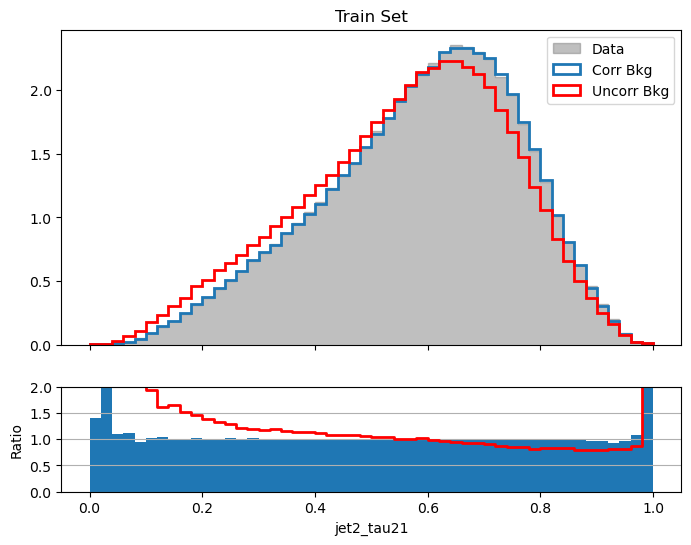

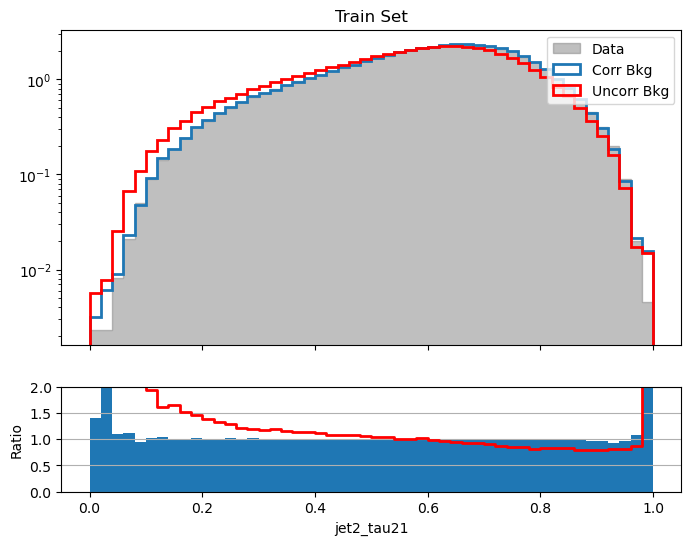

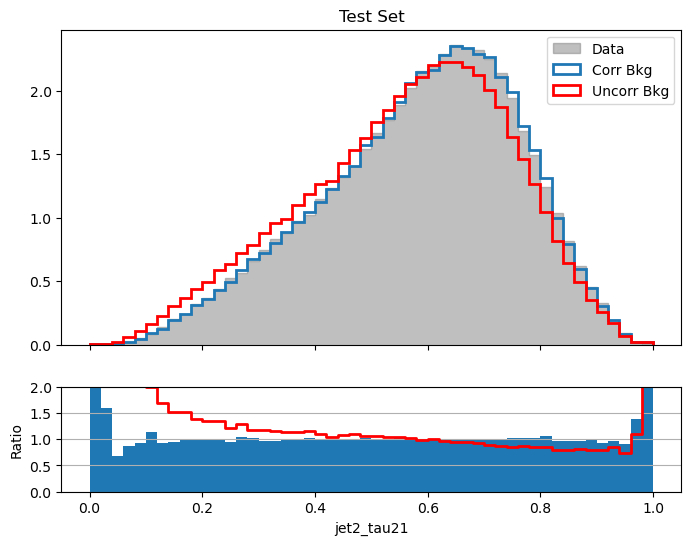

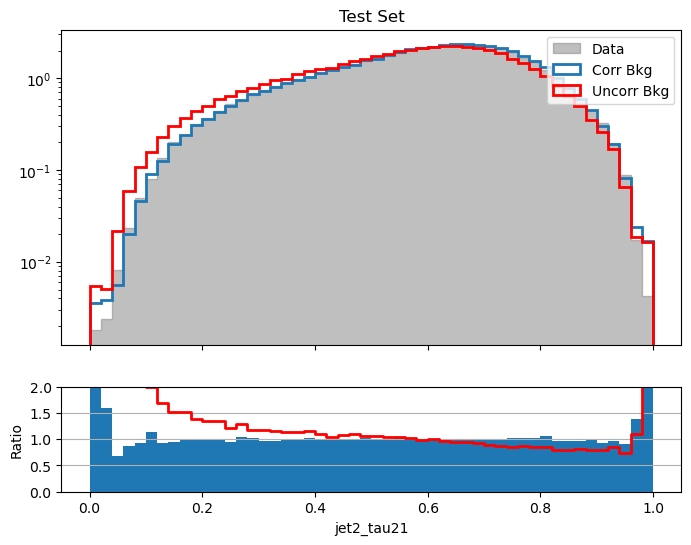

In [67]:
trainer.correctCurrent()
trainer.plotCurrent(50,ylim=[0,2])

In [68]:
trainer.stepForward()

## jet2 tau32

Training flow bkgFlow_step6_jet2_tau32


Loss: 0.789770582318306, p = 29: 100%|██████████| 499/499 [01:44<00:00,  4.75it/s]  


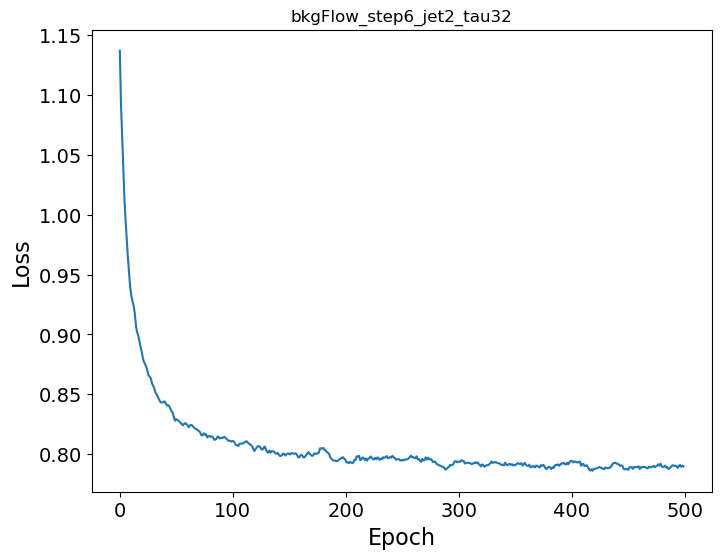

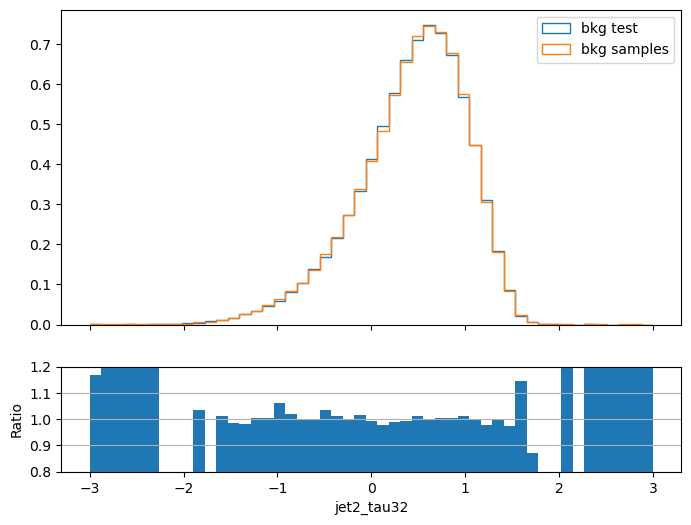

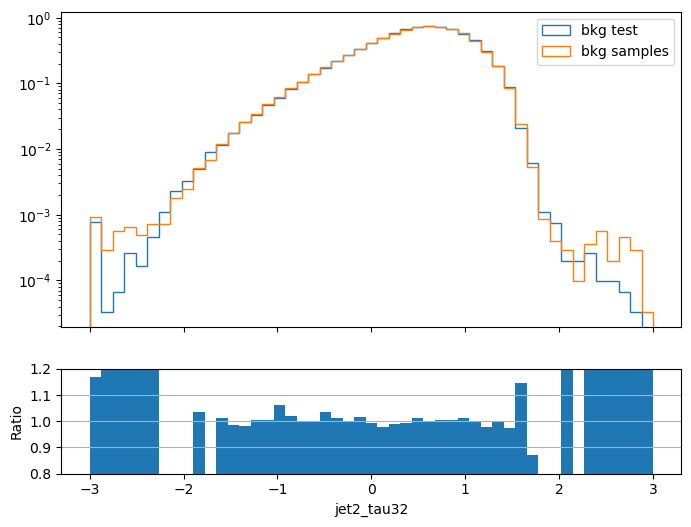

In [69]:
NF_kwargs = {"flow_type":"IRQS","tail_bound":3.2,"hidden_features":150,
             "num_layers":5,"num_bins":50,"num_blocks_per_layer":5,"tails":"linear",
            "dropout":0.0,"residual":False}
trainer.NF_kwargs = NF_kwargs
bs = 10000
n_epoch = 10
n_iter = n_epoch*b1_train.shape[0]//bs
trainer.trainCurrentBkg(patience=-1,n_epoch=n_iter,learning_rate=1e-3,bs=bs)
trainer.plotDensity(bkg=True)

Training flow dataFlow_step6_jet2_tau32


Loss: 0.7207790702581406, p = 38: 100%|██████████| 1000/1000 [04:01<00:00,  4.15it/s]


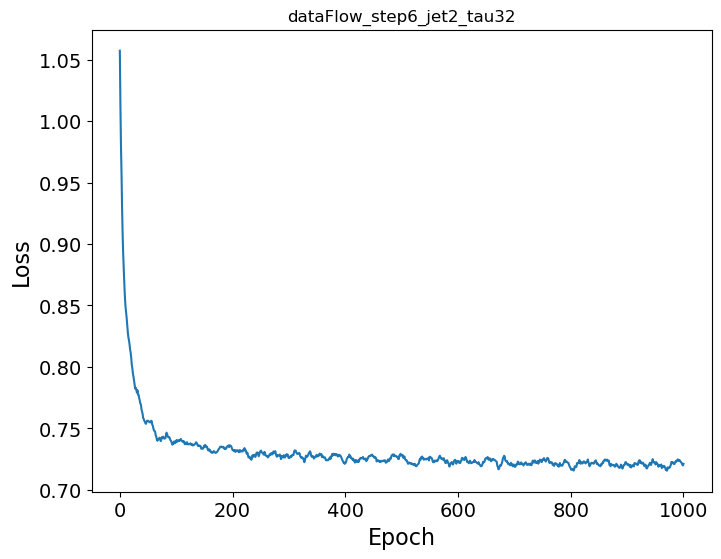

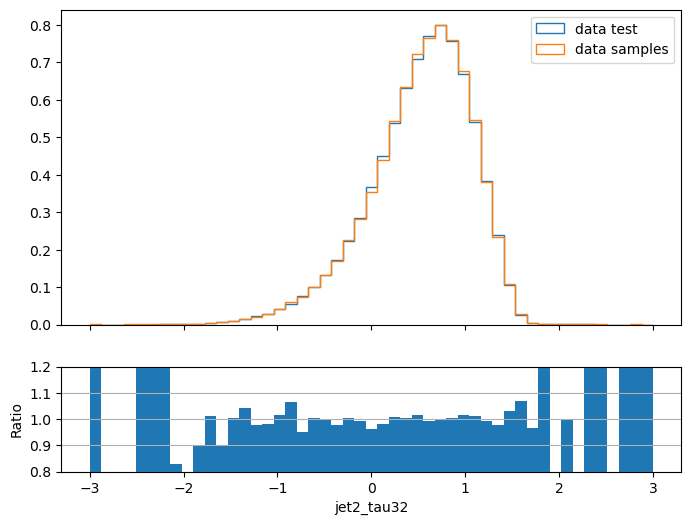

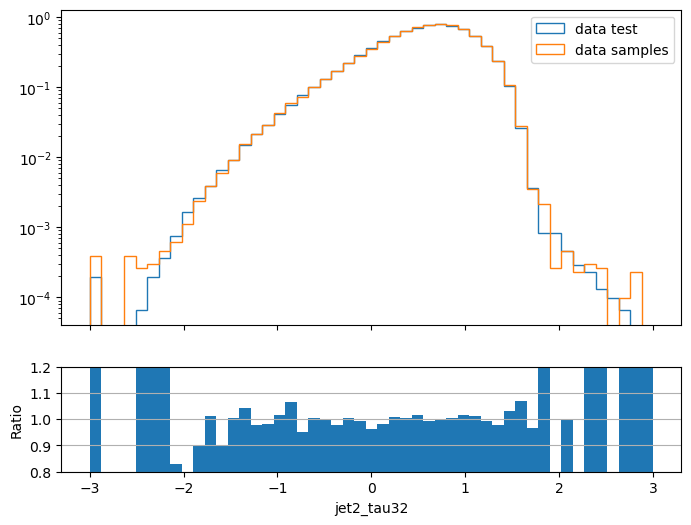

In [75]:
NF_kwargs = {"flow_type":"IRQS","tail_bound":3.2,"hidden_features":150,
             "num_layers":5,"num_bins":30,"num_blocks_per_layer":5,"tails":"linear",
            "dropout":0.0,"residual":False}
trainer.NF_kwargs = NF_kwargs
bs = 10000
n_epoch = 20
n_iter = n_epoch*rd_train.shape[0]//bs
trainer.trainCurrentData(patience=-1,n_epoch=n_iter,learning_rate=1e-3,bs=bs)
trainer.plotDensity(data=True)

100%|██████████| 25/25 [00:02<00:00, 12.12it/s]


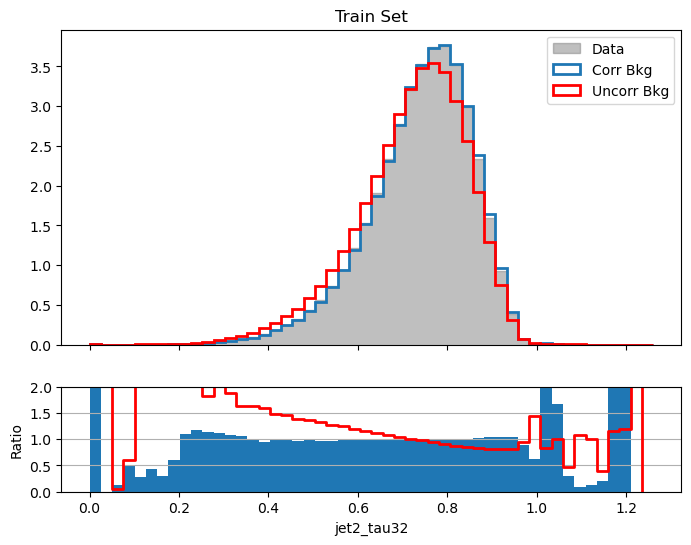

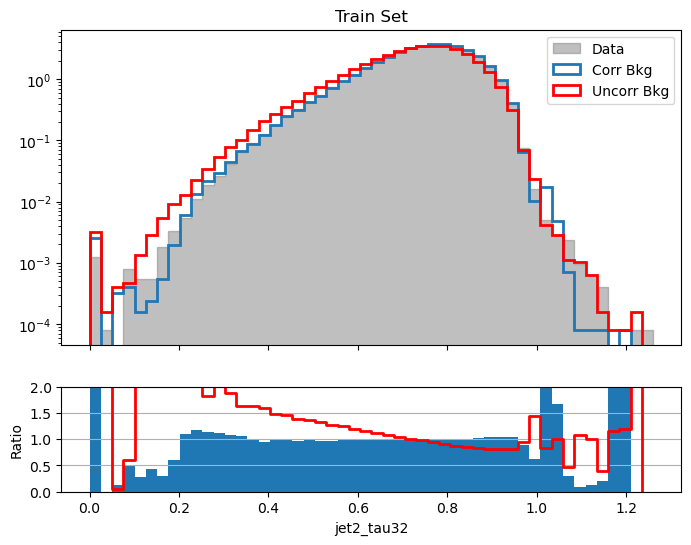

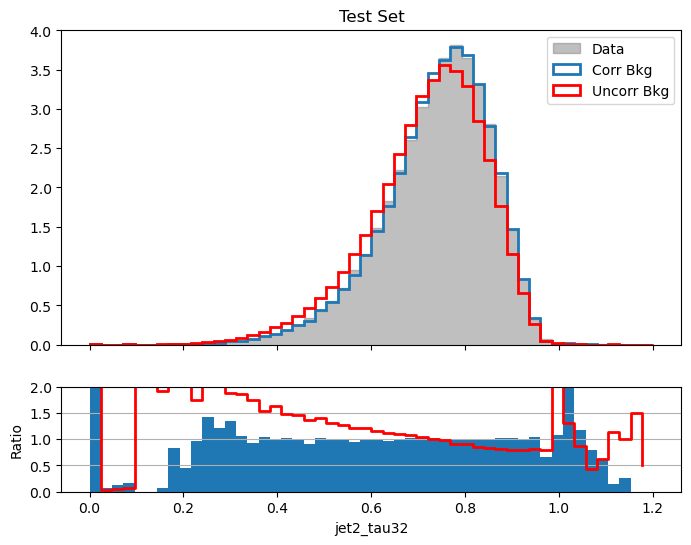

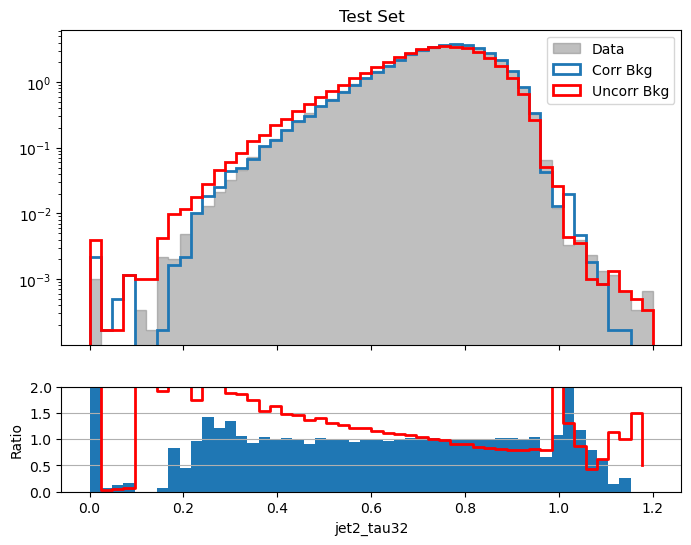

In [76]:
trainer.correctCurrent()
trainer.plotCurrent(50,ylim=[0,2])

In [77]:
trainer.stepForward()

## jet2 tau43

Training flow bkgFlow_step7_jet2_tau43


Loss: 0.5029146301746369, p = 76: 100%|██████████| 999/999 [03:45<00:00,  4.43it/s] 


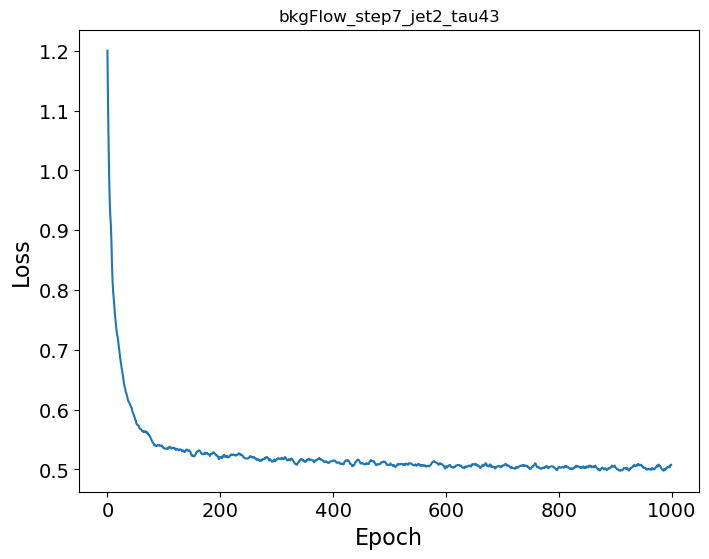

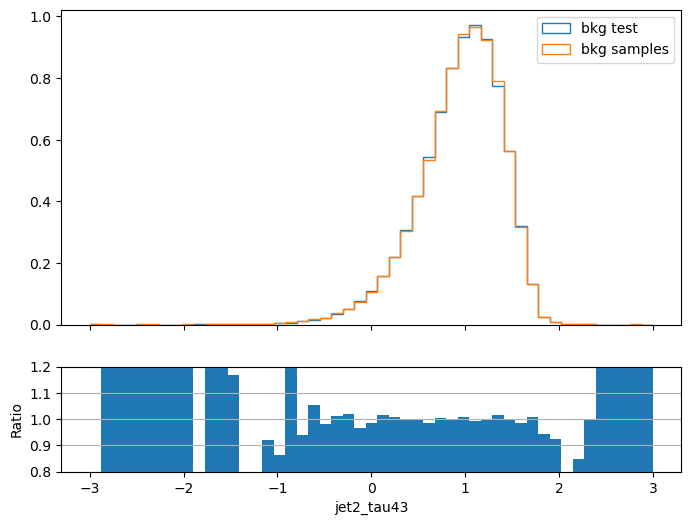

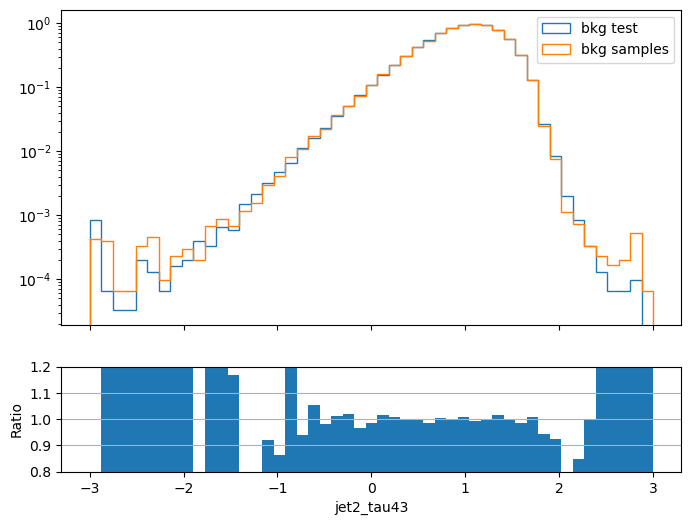

In [26]:
NF_kwargs = {"flow_type":"IRQS","tail_bound":3.2,"hidden_features":150,
             "num_layers":5,"num_bins":50,"num_blocks_per_layer":5,"tails":"linear",
            "dropout":0.0,"residual":False}
trainer.NF_kwargs = NF_kwargs
bs = 10000
n_epoch = 20
n_iter = n_epoch*b1_train.shape[0]//bs
trainer.trainCurrentBkg(patience=-1,n_epoch=n_iter,learning_rate=1e-3,bs=bs)
trainer.plotDensity(bkg=True)

Training flow dataFlow_step7_jet2_tau43


Loss: 0.43662806779146196, p = 100: 100%|██████████| 1000/1000 [03:47<00:00,  4.39it/s]


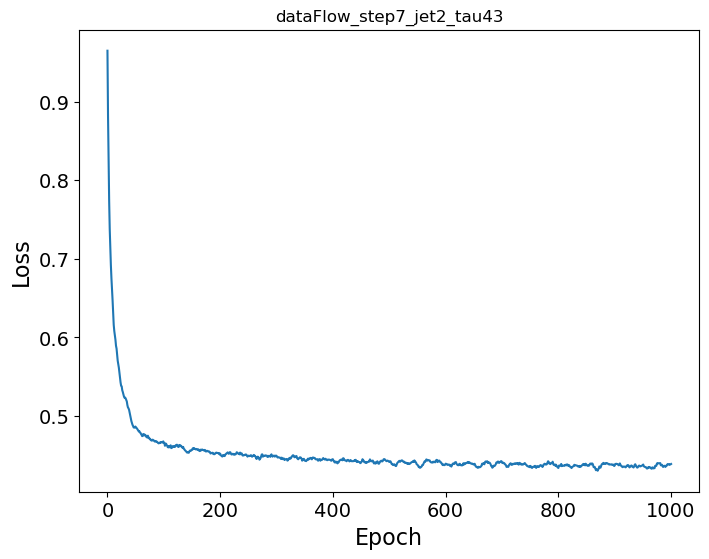

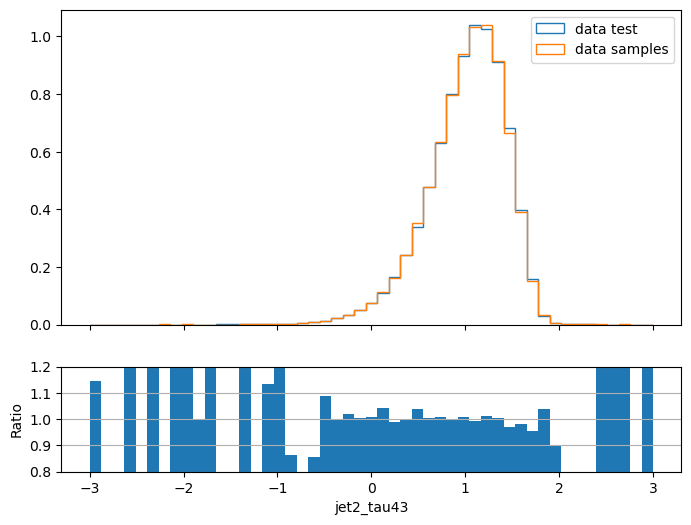

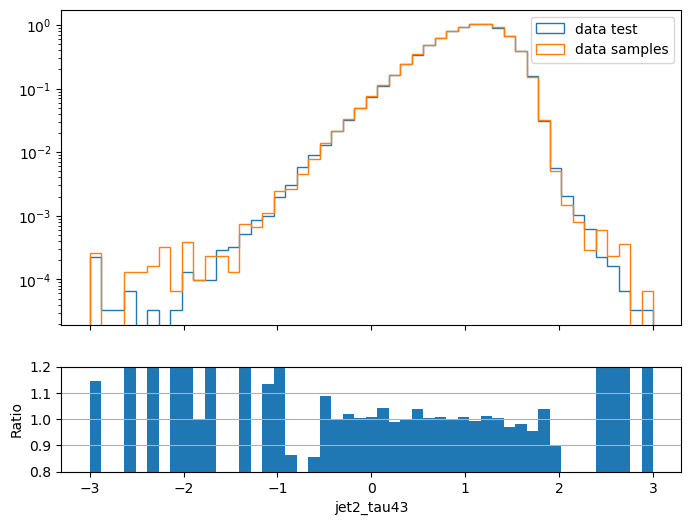

In [27]:
NF_kwargs = {"flow_type":"IRQS","tail_bound":3.2,"hidden_features":150,
             "num_layers":5,"num_bins":30,"num_blocks_per_layer":5,"tails":"linear",
            "dropout":0.0,"residual":False}
trainer.NF_kwargs = NF_kwargs
bs = 10000
n_epoch = 20
n_iter = n_epoch*rd_train.shape[0]//bs
trainer.trainCurrentData(patience=-1,n_epoch=n_iter,learning_rate=1e-3,bs=bs)
trainer.plotDensity(data=True)

100%|██████████| 25/25 [00:02<00:00, 12.33it/s]


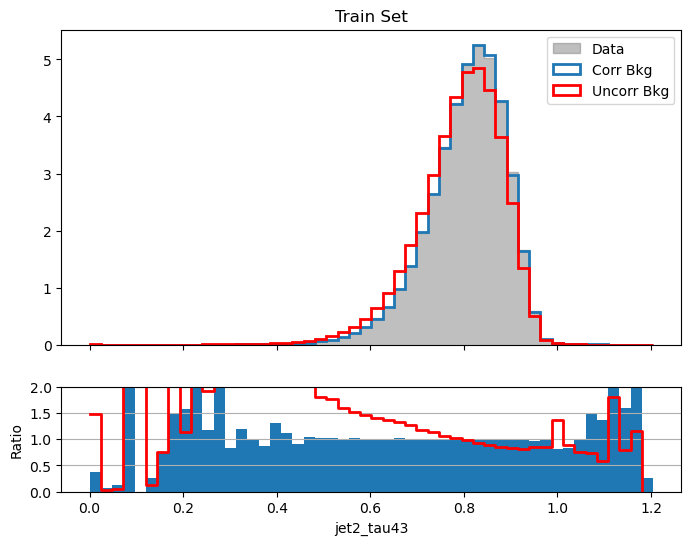

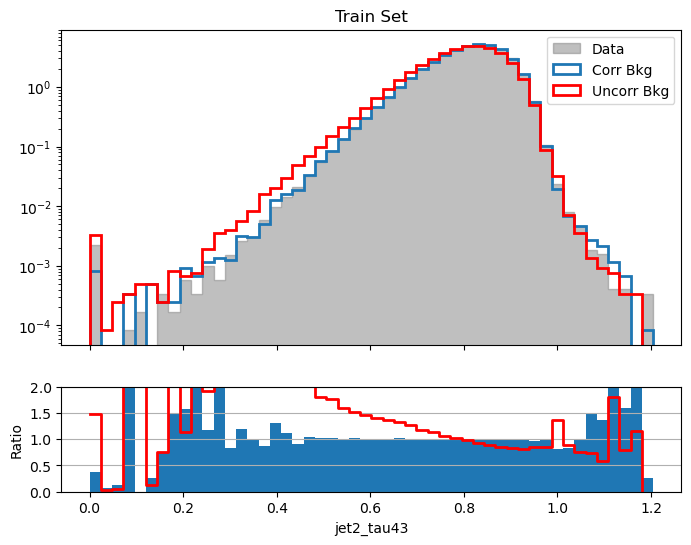

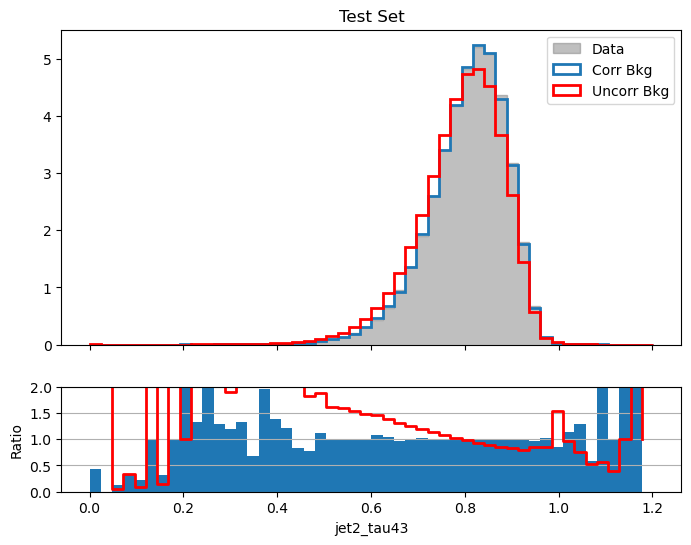

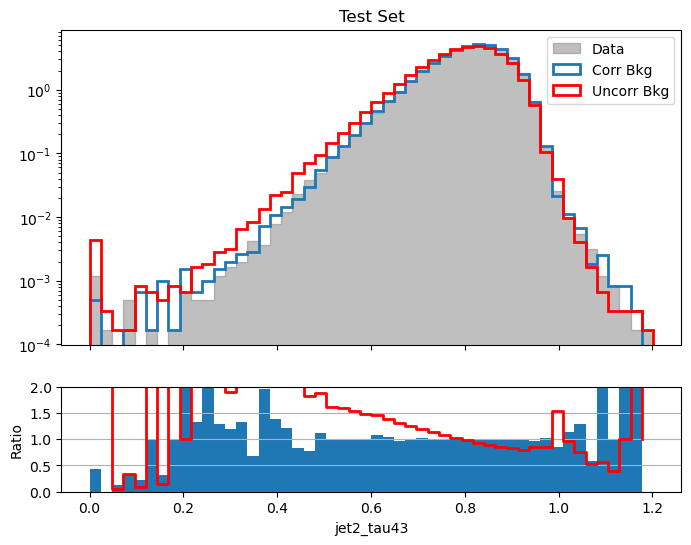

In [28]:
trainer.correctCurrent()
trainer.plotCurrent(50,ylim=[0,2])